# Fault Detection for Industrial Water Pumps Using Machine Learning and Deep Learning

**Dataset:** [Pump Sensor Data](https://www.kaggle.com/datasets/nphantawee/pump-sensor-data) (Kaggle)

**Task type:** Time-series binary classification for fault detection within a predictive-maintenance context.

**Motivation:** Unplanned pump failures are costly and disruptive. A model that can flag an
*anomalous* operating state - a temporary malfunction that self-recovers, or an outright
failure - automatically alerts maintenance teams the moment the machine leaves normal
operation, reducing downtime and repair cost.

**A note on terminology.** Predictive maintenance is the broader application domain: the
strategy of anticipating equipment failure and intervening before it occurs (Ahn et al.,
2023). The specific task solved in this notebook is *fault detection* - recognising that the
pump is currently in an abnormal state. As Section 3 establishes, `RECOVERING` always follows
a break rather than preceding it, so we do not claim the models forecast failures in advance.

**Original target — `machine_status` (3 classes):**

| Class | Meaning | Approx. count | Approx. % |
|---|---|---|---|
| `NORMAL` | steady-state operation | ~205,836 | ~93.4% |
| `RECOVERING` | temporary malfunction, auto-recovers | ~14,477 | ~6.6% |
| `BROKEN` | actual failure — needs maintenance | ~7 | ~0.003% |

`BROKEN` is so rare (7 rows out of 220,320) that no classifier can learn a separate decision
boundary for it, and any train/test split risks leaving it with zero examples on one side.
Following common practice for this dataset (and as suggested in the assessment brief), we
**reframe the problem as binary anomaly detection**:

* **Class 0 — `NORMAL`**
* **Class 1 — `ANOMALY`** = `RECOVERING` + `BROKEN`

This keeps the evaluation meaningful while preserving the real-world extreme class
imbalance (~6.6% positive class), which is itself a central discussion point: **accuracy is
misleading on this dataset** (predicting "NORMAL" for every row already scores ~93.4%
accuracy), so we lean on **precision, recall, F1-score, ROC-AUC and PR-AUC** for the anomaly
class, and use **class weighting** to counter the imbalance during training.

**Models compared:**

* Classical ML (tabular, per-timestep features): Decision Tree, Random Forest, Naïve Bayes
* Deep Learning (tabular, per-timestep features): Multilayer ANN (MLP)
* Deep Learning (sequential): LSTM, using rolling windows of past sensor readings

**Notebook structure** (mirrors the presentation outline):
1. Data loading
2. Dataset description & exploratory analysis
3. Data cleaning & preprocessing
4. Binary target creation & time-based train/test split
5. Feature engineering (rolling statistics, scaling)
6. Model training: Decision Tree, Random Forest, Naïve Bayes, ANN
7. Model evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC, PR-AUC)
8. Sequence preparation & LSTM
9. Model comparison
10. Conclusion & discussion
11. References (APA)


## 1. Imports & configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.21.0


## 2. Load data

The raw file is `sensor.csv`: ~220k rows recorded at 1-minute intervals from
1 April 2018 to 31 August 2018, with 52 sensor columns (`sensor_00` … `sensor_51`), a
`timestamp` column and the `machine_status` label.

In [2]:
df = pd.read_csv('sensor.csv')
df = df.drop(columns=['Unnamed: 0'])  # redundant row index saved by the original export
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print('Shape:', df.shape)
df.head()


Shape: (220320, 54)


,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


## 3. Dataset description & exploratory analysis

In [3]:
print(f"Time span: {df['timestamp'].min()}  ->  {df['timestamp'].max()}")
print(f"Number of rows: {len(df):,}")
print(f"Number of sensor columns: {df.columns.str.startswith('sensor_').sum()}")
df.info()


Time span: 2018-04-01 00:00:00  ->  2018-08-31 23:59:00
Number of rows: 220,320
Number of sensor columns: 52
<class 'pandas.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 54 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   timestamp       220320 non-null  datetime64[us]
 1   sensor_00       210112 non-null  float64       
 2   sensor_01       219951 non-null  float64       
 3   sensor_02       220301 non-null  float64       
 4   sensor_03       220301 non-null  float64       
 5   sensor_04       220301 non-null  float64       
 6   sensor_05       220301 non-null  float64       
 7   sensor_06       215522 non-null  float64       
 8   sensor_07       214869 non-null  float64       
 9   sensor_08       215213 non-null  float64       
 10  sensor_09       215725 non-null  float64       
 11  sensor_10       220301 non-null  float64       
 12  sensor_11       220301 non-null  float64    

                 count  percent
machine_status                 
NORMAL          205836   93.426
RECOVERING       14477    6.571
BROKEN               7    0.003


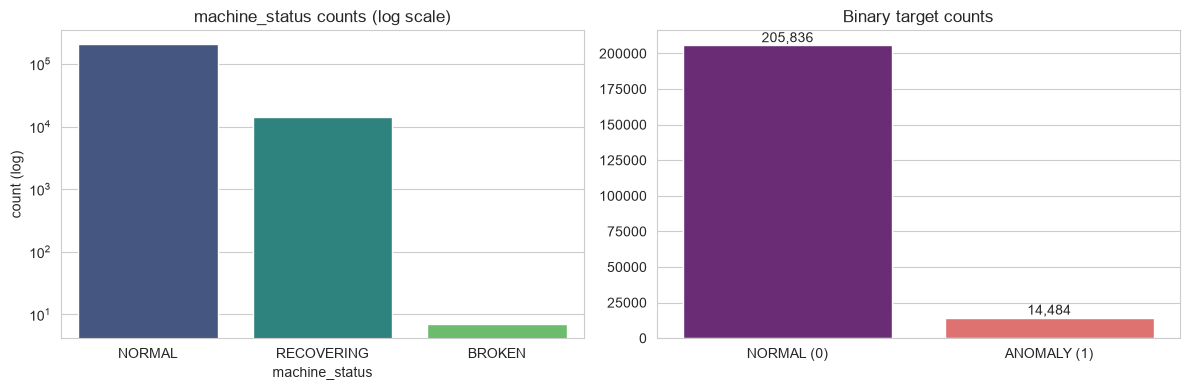

\nBinary class balance -> NORMAL: 205,836 (93.43%), ANOMALY: 14,484 (6.57%)


In [4]:
status_counts = df['machine_status'].value_counts()
status_pct = df['machine_status'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': status_counts, 'percent': status_pct.round(3)})
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=summary.index, y=summary['count'], ax=ax[0], palette='viridis')
ax[0].set_yscale('log')
ax[0].set_title('machine_status counts (log scale)')
ax[0].set_ylabel('count (log)')

df['anomaly_preview'] = df['machine_status'].isin(['RECOVERING', 'BROKEN']).astype(int)
binary_counts = df['anomaly_preview'].value_counts()
sns.barplot(x=['NORMAL (0)', 'ANOMALY (1)'], y=binary_counts.values, ax=ax[1], palette='magma')
ax[1].set_title('Binary target counts')
for i, v in enumerate(binary_counts.values):
    ax[1].text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(f"\\nBinary class balance -> NORMAL: {binary_counts[0]:,} ({binary_counts[0]/len(df)*100:.2f}%), "
      f"ANOMALY: {binary_counts[1]:,} ({binary_counts[1]/len(df)*100:.2f}%)")
df = df.drop(columns=['anomaly_preview'])


**Observation:** `NORMAL` dominates the dataset (~93%). Even after merging
`RECOVERING`+`BROKEN` into a single `ANOMALY` class, the positive class is still only
~6.6% of the data — this is an **extreme class imbalance** problem, and it is the single
most important characteristic to discuss when interpreting model results below.

           missing_count  missing_pct
sensor_15         220320       100.00
sensor_50          77017        34.96
sensor_51          15383         6.98
sensor_00          10208         4.63
sensor_07           5451         2.47
sensor_08           5107         2.32
sensor_06           4798         2.18
sensor_09           4595         2.09
sensor_01            369         0.17
sensor_30            261         0.12
sensor_29             72         0.03
sensor_32             68         0.03
sensor_18             46         0.02
sensor_17             46         0.02
sensor_22             41         0.02
sensor_25             36         0.02
sensor_16             31         0.01
sensor_41             27         0.01
sensor_39             27         0.01
sensor_40             27         0.01
sensor_42             27         0.01
sensor_38             27         0.01
sensor_43             27         0.01
sensor_44             27         0.01
sensor_45             27         0.01
sensor_46   

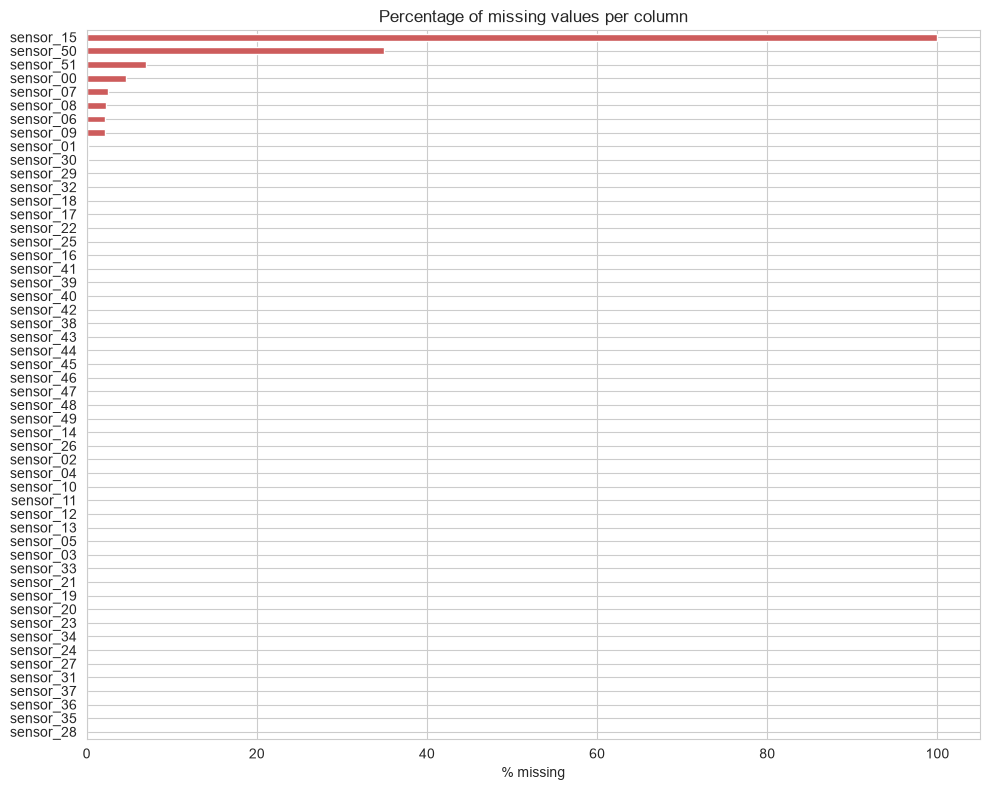

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_summary)

fig, ax = plt.subplots(figsize=(10, 8))
missing_summary['missing_pct'].plot(kind='barh', ax=ax, color='indianred')
ax.set_title('Percentage of missing values per column')
ax.set_xlabel('% missing')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


`sensor_15` is **100% missing** (a known artefact of this dataset — the sensor never
recorded a value) and will be dropped entirely. `sensor_50` and `sensor_51` have high
missingness (~35% and ~7% respectively); a handful of other sensors have small numbers of
missing values (< 5%). Because these are continuous physical readings sampled once per
minute, we treat missingness as short sensor dropouts and use **time-based interpolation**
rather than a single global mean/median fill.

Total sensor columns before cleaning: 52


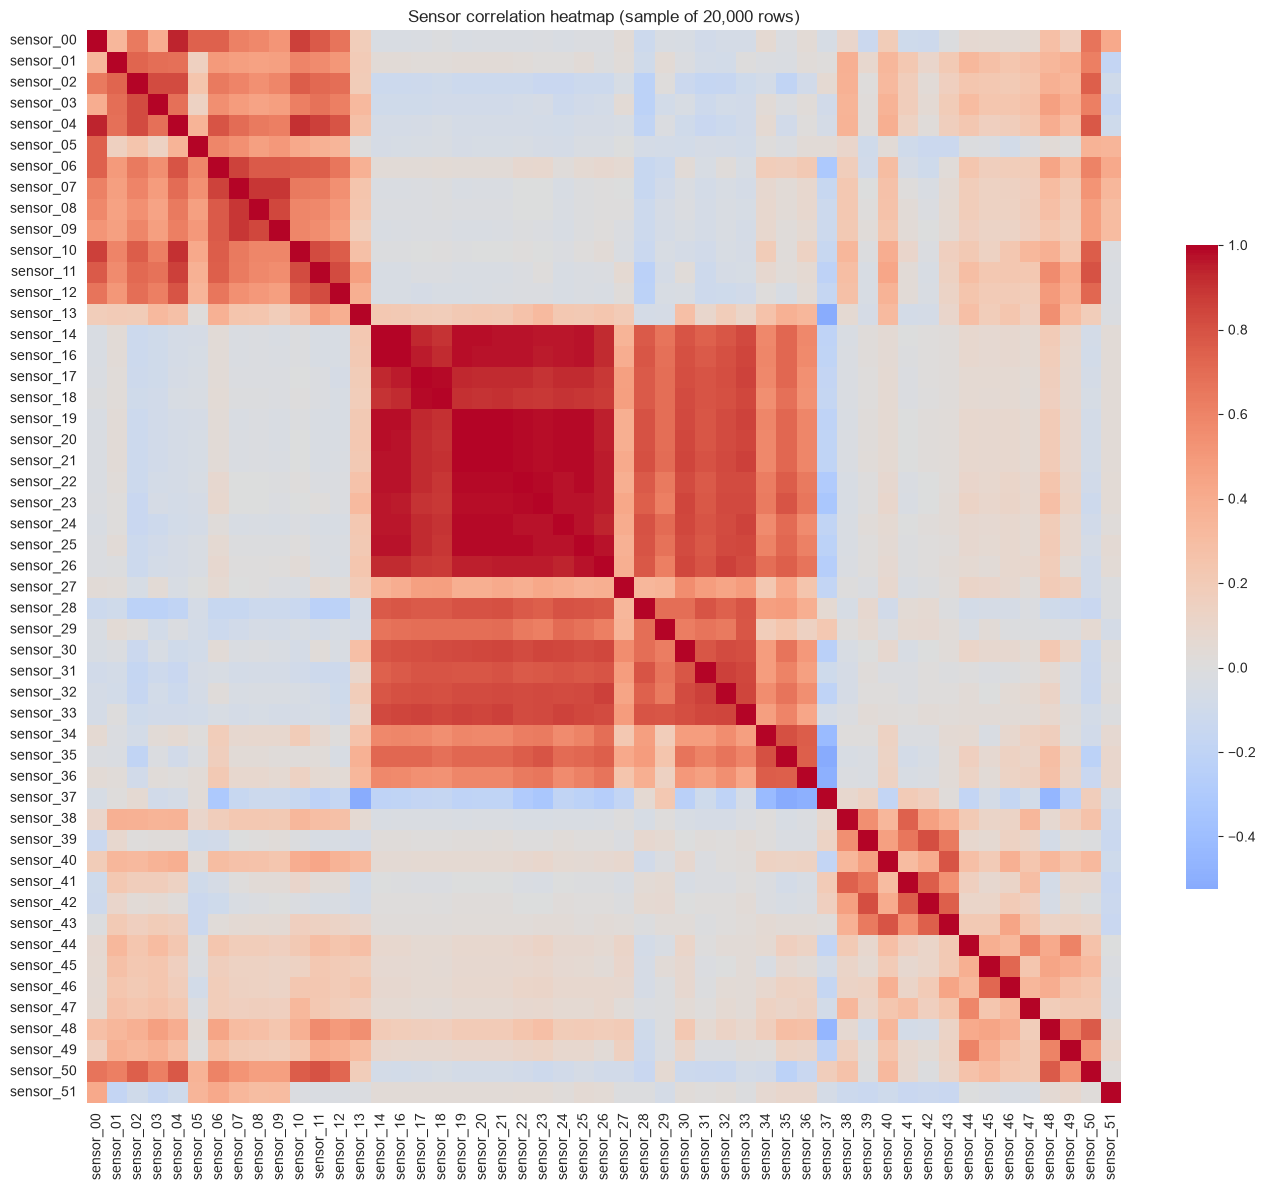

In [6]:
sensor_cols_all = [c for c in df.columns if c.startswith('sensor_')]
print(f'Total sensor columns before cleaning: {len(sensor_cols_all)}')

# Correlation heatmap on a random sample of rows (for speed / readability)
sample_df = df[sensor_cols_all].drop(columns=['sensor_15']).sample(20000, random_state=RANDOM_STATE)
corr = sample_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, cbar_kws={'shrink': 0.6})
plt.title('Sensor correlation heatmap (sample of 20,000 rows)')
plt.tight_layout()
plt.show()


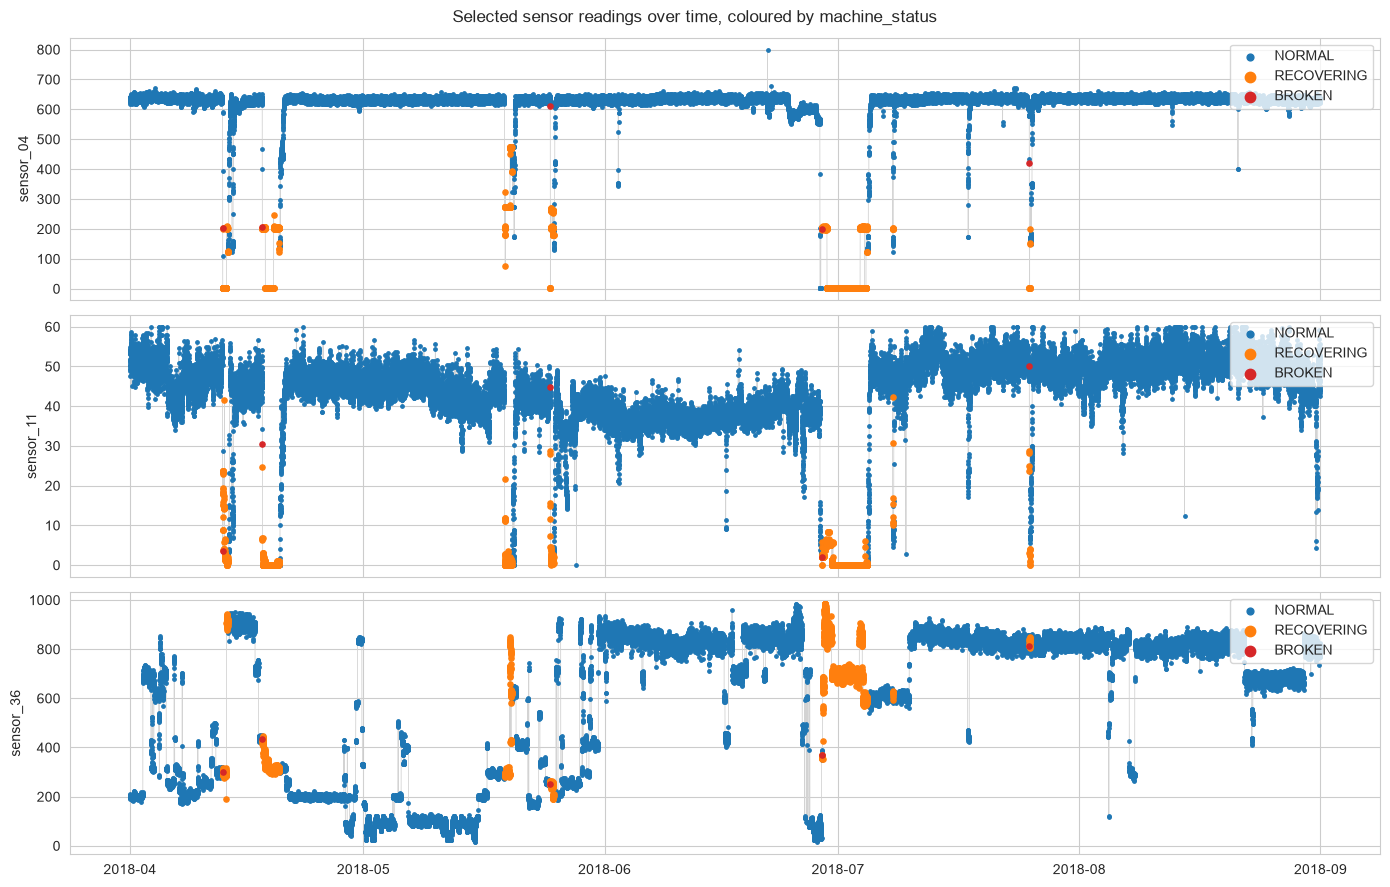

In [7]:
# Visualise a few representative sensors over time, coloured by machine status
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
plot_sensors = ['sensor_04', 'sensor_11', 'sensor_36']
status_colors = {'NORMAL': 'tab:blue', 'RECOVERING': 'tab:orange', 'BROKEN': 'tab:red'}

plot_df = df.iloc[::5]  # subsample every 5th row purely for plotting speed
for ax, s in zip(axes, plot_sensors):
    ax.plot(plot_df['timestamp'], plot_df[s], color='lightgray', linewidth=0.6, zorder=1)
    for status, color in status_colors.items():
        mask = plot_df['machine_status'] == status
        if mask.any():
            ax.scatter(plot_df.loc[mask, 'timestamp'], plot_df.loc[mask, s],
                       s=6 if status == 'NORMAL' else 14, color=color, label=status, zorder=2)
    ax.set_ylabel(s)
    ax.legend(loc='upper right', markerscale=2)
plt.suptitle('Selected sensor readings over time, coloured by machine_status')
plt.tight_layout()
plt.show()


### Sensor value distributions by machine status

Beyond time-series plots, it helps to check whether individual sensors have a noticeably
different *distribution* of values when the pump is `RECOVERING` or `BROKEN` versus
`NORMAL`. A strong distributional shift (a box sitting at a different level, or a much wider
spread) is an early, model-free signal that a sensor will be genuinely useful for
classification — as opposed to a sensor whose boxes all overlap, which is unlikely to help
much regardless of which algorithm is used.

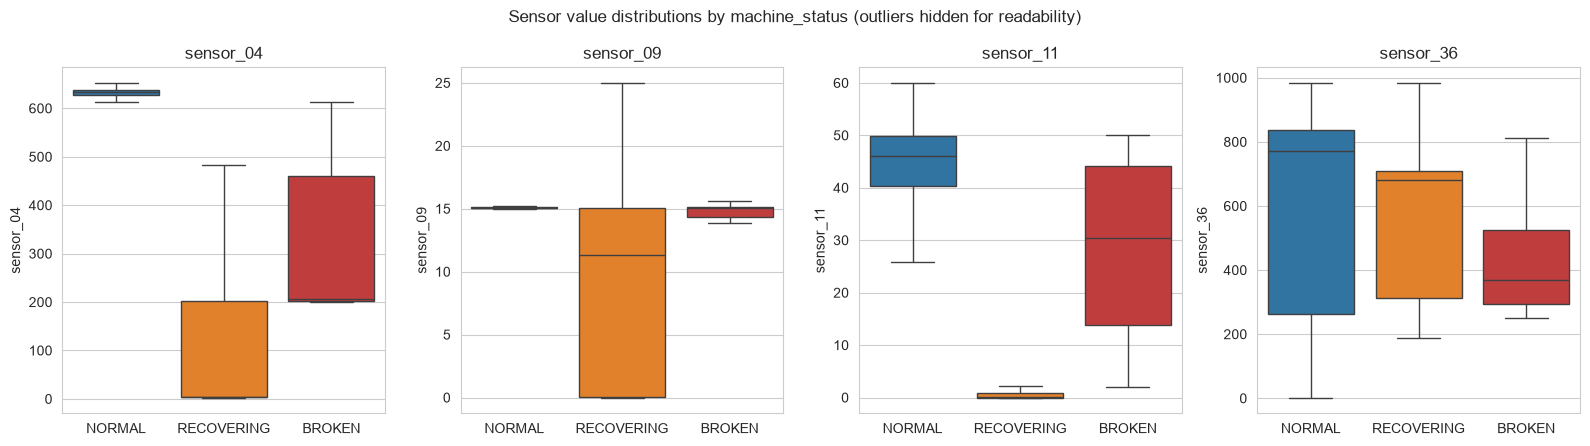

In [8]:
eda_sensors = ['sensor_04', 'sensor_09', 'sensor_11', 'sensor_36']

fig, axes = plt.subplots(1, len(eda_sensors), figsize=(16, 4.5))
for ax, s in zip(axes, eda_sensors):
    sns.boxplot(data=df, x='machine_status', y=s, ax=ax,
                order=['NORMAL', 'RECOVERING', 'BROKEN'],
                palette=status_colors, showfliers=False)
    ax.set_title(s)
    ax.set_xlabel('')
plt.suptitle('Sensor value distributions by machine_status (outliers hidden for readability)')
plt.tight_layout()
plt.show()


### Anomaly episode duration analysis

`RECOVERING`/`BROKEN` events don't occur as isolated single-minute blips — they form
contiguous episodes lasting anywhere from a few minutes to several days. Understanding how
many episodes there are and how long they typically last matters for predictive
maintenance: it sets expectations for the realistic "detection window" a model has to work
with, and tells us whether a useful alerting system needs to catch every minute of an
episode or just flag it early. We'll reuse this `episodes` table later to check, per model,
whether each real episode was actually detected.

Number of distinct anomaly episodes: 7
                start                 end  duration_min  contains_broken
0 2018-04-12 21:55:00 2018-04-13 13:39:00           945             True
1 2018-04-18 00:30:00 2018-04-20 04:20:00          3111             True
2 2018-05-19 03:18:00 2018-05-20 01:10:00          1313             True
3 2018-05-25 00:30:00 2018-05-25 10:35:00           606             True
4 2018-06-28 22:00:00 2018-07-04 17:50:00          8391             True
5 2018-07-08 00:11:00 2018-07-08 00:52:00            42             True
6 2018-07-25 14:00:00 2018-07-25 15:15:00            76             True

count       7.000000
mean     2069.142857
std      2975.161252
min        42.000000
25%       341.000000
50%       945.000000
75%      2212.000000
max      8391.000000
Name: duration_min, dtype: float64


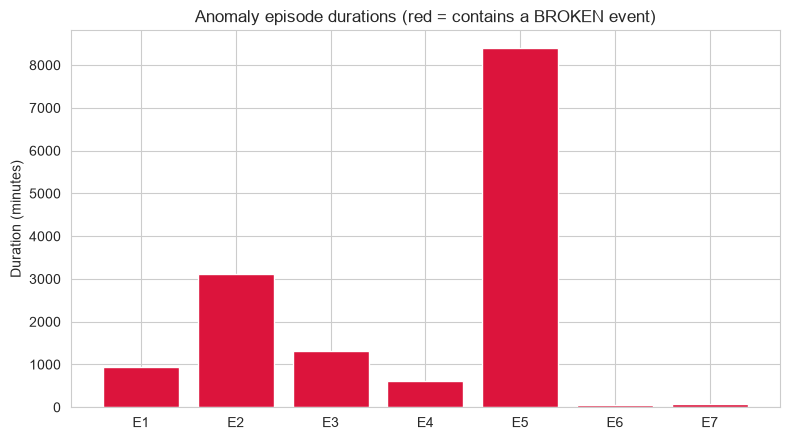

In [9]:
anomaly_mask = df['machine_status'].isin(['RECOVERING', 'BROKEN'])
episode_id = (anomaly_mask != anomaly_mask.shift()).cumsum()

episodes = (
    df[anomaly_mask]
    .groupby(episode_id[anomaly_mask])
    .agg(start=('timestamp', 'min'), end=('timestamp', 'max'),
         duration_min=('timestamp', 'count'),
         n_broken=('machine_status', lambda s: (s == 'BROKEN').sum()))
    .reset_index(drop=True)
)
episodes['contains_broken'] = episodes['n_broken'] > 0

print(f'Number of distinct anomaly episodes: {len(episodes)}')
print(episodes[['start', 'end', 'duration_min', 'contains_broken']])
print()
print(episodes['duration_min'].describe())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(len(episodes)), episodes['duration_min'],
       color=['crimson' if b else 'darkorange' for b in episodes['contains_broken']])
ax.set_xticks(range(len(episodes)))
ax.set_xticklabels([f'E{i+1}' for i in range(len(episodes))])
ax.set_ylabel('Duration (minutes)')
ax.set_title('Anomaly episode durations (red = contains a BROKEN event)')
plt.tight_layout()
plt.show()


### When do anomalies happen? Hour-of-day and day-of-week patterns

Checking whether anomalies cluster around particular times of day or particular days of the
week helps distinguish genuine equipment faults from something more mundane, like a
scheduled maintenance or startup routine — and gives useful context to discuss during the
presentation's dataset description.

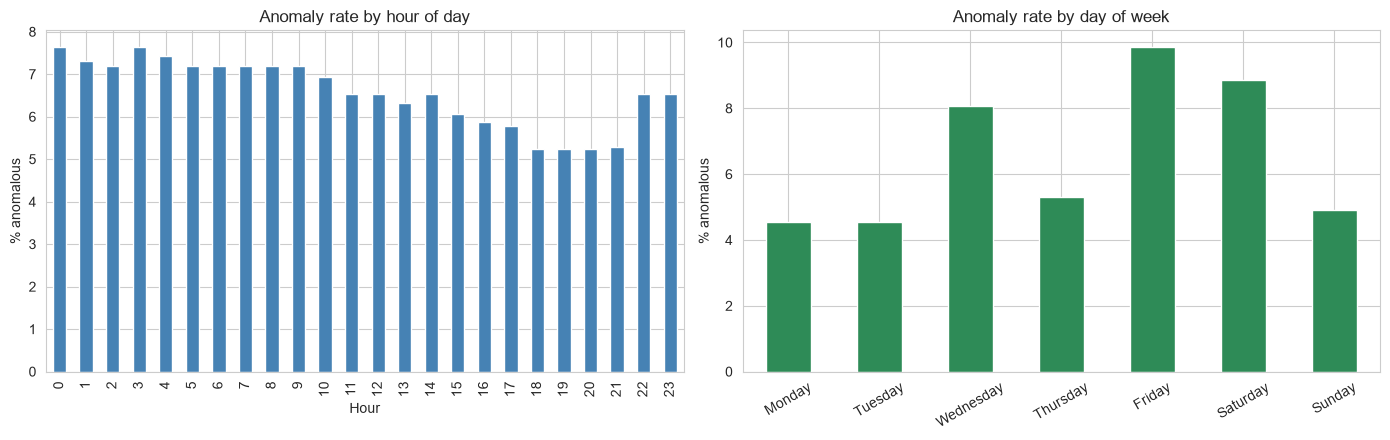

In [10]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hour_of_day = df['timestamp'].dt.hour
day_of_week = df['timestamp'].dt.day_name()

hourly_rate = anomaly_mask.groupby(hour_of_day).mean() * 100
dow_rate = (anomaly_mask.groupby(day_of_week).mean() * 100).reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
hourly_rate.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Anomaly rate by hour of day')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('% anomalous')

dow_rate.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Anomaly rate by day of week')
axes[1].set_xlabel(''); axes[1].set_ylabel('% anomalous')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### What does the `ANOMALY` label actually represent?

Before modelling, it is worth establishing *when* the positive class occurs relative to the
failures themselves, because that determines what an accurate model would actually be doing.

In [11]:
# Reconstruct contiguous label runs to see how the three states are ordered.
p1_runs = (df['machine_status'] != df['machine_status'].shift()).cumsum()
p1_blocks = df.groupby(p1_runs).agg(
    status=('machine_status', 'first'),
    minutes=('machine_status', 'size'),
)
p1_broken_rows = df.index[df['machine_status'] == 'BROKEN'].tolist()

print(f"BROKEN events: {len(p1_broken_rows)}")
print(f"RECOVERING episodes: {(p1_blocks['status'] == 'RECOVERING').sum()}")
print()
print("Label sequence immediately around each BROKEN event:")
for r in p1_broken_rows:
    before = df['machine_status'].iloc[max(0, r - 2):r].tolist()
    after = df['machine_status'].iloc[r + 1:r + 3].tolist()
    print(f"  {df['timestamp'].iloc[r]}   {before} -> BROKEN -> {after}")

BROKEN events: 7
RECOVERING episodes: 7

Label sequence immediately around each BROKEN event:
  2018-04-12 21:55:00   ['NORMAL', 'NORMAL'] -> BROKEN -> ['RECOVERING', 'RECOVERING']
  2018-04-18 00:30:00   ['NORMAL', 'NORMAL'] -> BROKEN -> ['RECOVERING', 'RECOVERING']
  2018-05-19 03:18:00   ['NORMAL', 'NORMAL'] -> BROKEN -> ['RECOVERING', 'RECOVERING']
  2018-05-25 00:30:00   ['NORMAL', 'NORMAL'] -> BROKEN -> ['RECOVERING', 'RECOVERING']
  2018-06-28 22:00:00   ['NORMAL', 'NORMAL'] -> BROKEN -> ['RECOVERING', 'RECOVERING']
  2018-07-08 00:11:00   ['NORMAL', 'NORMAL'] -> BROKEN -> ['RECOVERING', 'RECOVERING']
  2018-07-25 14:00:00   ['NORMAL', 'NORMAL'] -> BROKEN -> ['RECOVERING', 'RECOVERING']


**This changes how the results must be interpreted.** Every `BROKEN` event lasts exactly one
minute and is immediately followed by a long `RECOVERING` episode - the repair and restart
period. `RECOVERING` therefore always occurs *after* the failure, never before it.

Because `RECOVERING` supplies 14,477 of the 14,484 positive rows, roughly **99.95% of the
`ANOMALY` class describes a pump that has already failed**. The task is honestly described as
**fault detection** - recognising that the machine is currently in an abnormal state - rather
than failure *prediction*. Detecting a fault state automatically still has operational value,
but we do not claim the models forecast failures in advance.

### How separable are the two classes?

If the positive class is a post-failure state, the sensors should look dramatically different
during anomalies, and every model should score very highly. Establishing that here means the
near-perfect metrics later in the notebook are explained rather than left as a surprise.

In [12]:
# Standardised gap between NORMAL and ANOMALY for every usable sensor.
p1_df = df.drop(columns=['sensor_15']).copy()
p1_df['anomaly'] = p1_df['machine_status'].isin(['RECOVERING', 'BROKEN']).astype(int)
p1_sensors = [c for c in p1_df.columns if c.startswith('sensor_')]

p1_norm_mean = p1_df.loc[p1_df['anomaly'] == 0, p1_sensors].mean()
p1_norm_std = p1_df.loc[p1_df['anomaly'] == 0, p1_sensors].std()
p1_anom_mean = p1_df.loc[p1_df['anomaly'] == 1, p1_sensors].mean()

p1_sep = pd.DataFrame({
    'NORMAL_mean': p1_norm_mean,
    'ANOMALY_mean': p1_anom_mean,
    'gap_in_SD': ((p1_anom_mean - p1_norm_mean) / p1_norm_std).abs(),
}).sort_values('gap_in_SD', ascending=False)

print("Top 10 sensors by separation between NORMAL and ANOMALY:")
display(p1_sep.head(10).round(2))
print()
print(f"Sensors separated by more than 1 SD: {(p1_sep['gap_in_SD'] > 1).sum()} of {len(p1_sensors)}")
print(f"Largest separation: {p1_sep['gap_in_SD'].max():.1f} SD ({p1_sep['gap_in_SD'].idxmax()})")
print()
print("A gap of this size means the classes are almost linearly separable, which is why")
print("every model below reaches a very high ROC-AUC. The scores reflect how distinctive")
print("a failed pump looks, not unusually sophisticated modelling.")

Top 10 sensors by separation between NORMAL and ANOMALY:


,NORMAL_mean,ANOMALY_mean,gap_in_SD
sensor_07,16.17,8.50,12.77
sensor_09,15.09,8.82,10.93
sensor_08,15.48,9.12,10.80
sensor_04,625.67,93.15,10.48
sensor_00,2.42,0.06,9.75
sensor_06,13.87,5.79,9.34
sensor_10,44.27,1.69,7.04
sensor_02,51.64,39.93,6.23
sensor_11,44.77,1.38,5.71
sensor_12,31.17,0.20,4.55



Sensors separated by more than 1 SD: 20 of 51
Largest separation: 12.8 SD (sensor_07)

A gap of this size means the classes are almost linearly separable, which is why
every model below reaches a very high ROC-AUC. The scores reflect how distinctive
a failed pump looks, not unusually sophisticated modelling.


### Is there any warning *before* a failure?

The natural follow-up is whether the sensors move at all in the period leading up to a break.
That is the genuinely predictive problem, and the one a maintenance team would want solved. We
do not model it here, but quantifying how much weaker the signal is sets a realistic
expectation and defines the clearest extension to this work.

In [13]:
# Compare the 60 minutes BEFORE each failure against ordinary NORMAL operation.
p1_window = 60
p1_pre_idx = []
for r in p1_broken_rows:
    p1_pre_idx.extend(range(max(0, r - p1_window), r))

p1_pre = p1_df.loc[p1_pre_idx, p1_sensors]
p1_base = p1_df.loc[p1_df['anomaly'] == 0, p1_sensors]
p1_pre_gap = ((p1_pre.mean() - p1_base.mean()) / p1_base.std()).abs().sort_values(ascending=False)

p1_compare = pd.DataFrame({
    'gap_before_failure_SD': p1_pre_gap,
    'gap_during_anomaly_SD': p1_sep['gap_in_SD'],
}).sort_values('gap_before_failure_SD', ascending=False)

print(f"Sensor movement in the {p1_window} minutes before failure, versus during the anomaly:")
display(p1_compare.head(8).round(2))
print()
print(f"Sensors shifting > 1 SD before failure: {(p1_pre_gap > 1).sum()} of {len(p1_sensors)}")
print(f"Sensors shifting > 1 SD during anomaly: {(p1_sep['gap_in_SD'] > 1).sum()} of {len(p1_sensors)}")
print()
print("There is some early warning, but it is several times weaker than the post-failure")
print("signature, and true prediction would have only 7 positive events to learn from.")
print("That is a substantially harder problem and the clearest direction for future work.")

Sensor movement in the 60 minutes before failure, versus during the anomaly:


,gap_before_failure_SD,gap_during_anomaly_SD
sensor_04,2.01,10.48
sensor_00,1.48,9.75
sensor_10,1.20,7.04
sensor_05,1.17,3.23
sensor_01,0.98,4.00
sensor_38,0.95,2.00
sensor_06,0.78,9.34
sensor_39,0.76,0.14



Sensors shifting > 1 SD before failure: 4 of 51
Sensors shifting > 1 SD during anomaly: 20 of 51

There is some early warning, but it is several times weaker than the post-failure
signature, and true prediction would have only 7 positive events to learn from.
That is a substantially harder problem and the clearest direction for future work.


### Do the engineered rolling features actually carry signal?

Half of the 150 tabular features are rolling means and rolling standard deviations, so it is
worth testing directly whether they add anything rather than asserting that they do.

The question is specific: the raw sensor *levels* barely move before a failure (only a
handful shift by more than 1 SD). Does short-term **variability** move earlier than the
level does? If a sensor becomes unstable before it drifts, rolling standard deviation would
pick that up while the raw reading still looks normal.


Sensors shifting more than 1 SD (out of 51):


,Raw level,Rolling std (5 min)
60 min BEFORE failure,4,8
DURING anomaly,20,4



Sensors where rolling std gives the larger pre-failure signal: 25 of 51

Largest gains (rolling std warns, raw level does not):


,raw_pre,rollstd_pre,gain
sensor_33,0.32,2.18,1.86
sensor_32,0.16,0.96,0.79
sensor_42,0.20,0.90,0.70
sensor_07,0.63,1.18,0.55
sensor_00,1.48,1.97,0.49
sensor_41,0.60,1.09,0.49


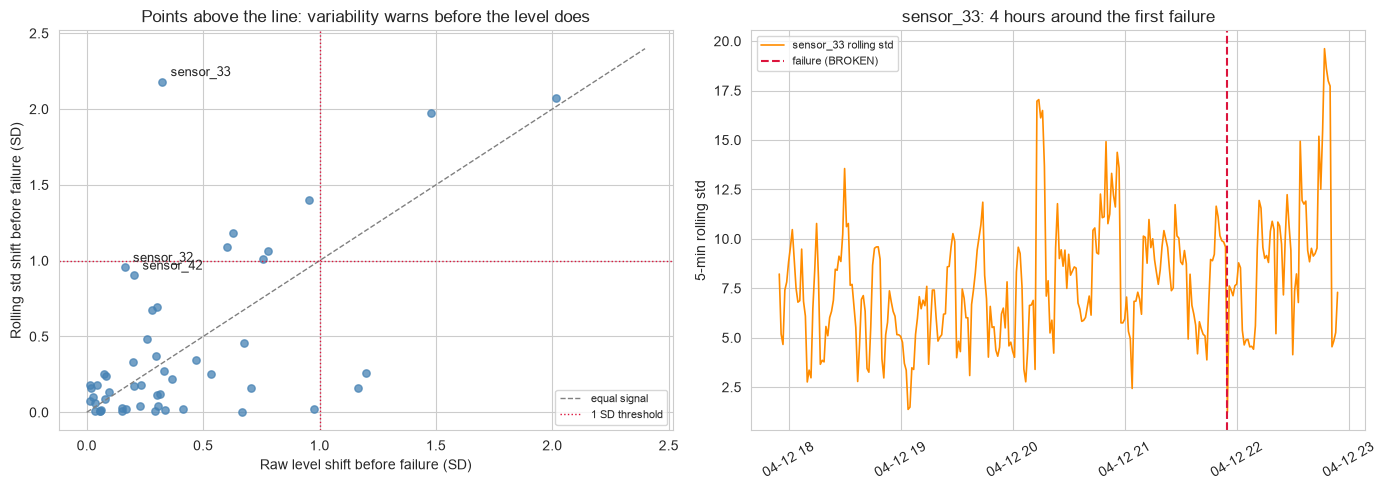

In [14]:
# Rolling standard deviation, computed the same way as the modelling features
# (5-minute backward-looking window) so this measures exactly what the models receive.
p1_rollstd = p1_df[p1_sensors].rolling(5, min_periods=1).std().fillna(0)
p1_normal_mask = p1_df['anomaly'] == 0
p1_anom_idx = p1_df.index[p1_df['anomaly'] == 1]

def standardised_gap(frame, idx, normal_mask):
    """|mean(idx) - mean(normal)| expressed in normal-operation standard deviations."""
    base_mu = frame[normal_mask].mean()
    base_sd = frame[normal_mask].std().replace(0, np.nan)
    return ((frame.loc[idx].mean() - base_mu) / base_sd).abs()

raw_pre        = standardised_gap(p1_df[p1_sensors], p1_pre_idx,  p1_normal_mask)
rollstd_pre    = standardised_gap(p1_rollstd,        p1_pre_idx,  p1_normal_mask)
raw_during     = standardised_gap(p1_df[p1_sensors], p1_anom_idx, p1_normal_mask)
rollstd_during = standardised_gap(p1_rollstd,        p1_anom_idx, p1_normal_mask)

signal_summary = pd.DataFrame({
    'Raw level': [(raw_pre > 1).sum(), (raw_during > 1).sum()],
    'Rolling std (5 min)': [(rollstd_pre > 1).sum(), (rollstd_during > 1).sum()],
}, index=['60 min BEFORE failure', 'DURING anomaly'])
print(f'Sensors shifting more than 1 SD (out of {len(p1_sensors)}):')
display(signal_summary)

cmp_signal = pd.DataFrame({'raw_pre': raw_pre, 'rollstd_pre': rollstd_pre}).dropna()
cmp_signal['gain'] = cmp_signal['rollstd_pre'] - cmp_signal['raw_pre']
print('\nSensors where rolling std gives the larger pre-failure signal: '
      f"{(cmp_signal['gain'] > 0).sum()} of {len(cmp_signal)}")
print('\nLargest gains (rolling std warns, raw level does not):')
display(cmp_signal.sort_values('gain', ascending=False).head(6).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(cmp_signal['raw_pre'], cmp_signal['rollstd_pre'], s=28, alpha=0.75, color='steelblue')
lim = float(max(cmp_signal['raw_pre'].max(), cmp_signal['rollstd_pre'].max())) * 1.1
ax.plot([0, lim], [0, lim], '--', color='gray', linewidth=1, label='equal signal')
ax.axhline(1, color='crimson', linestyle=':', linewidth=1, label='1 SD threshold')
ax.axvline(1, color='crimson', linestyle=':', linewidth=1)
for s in cmp_signal.sort_values('gain', ascending=False).head(3).index:
    ax.annotate(s, (cmp_signal.loc[s, 'raw_pre'], cmp_signal.loc[s, 'rollstd_pre']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('Raw level shift before failure (SD)')
ax.set_ylabel('Rolling std shift before failure (SD)')
ax.set_title('Points above the line: variability warns before the level does')
ax.legend(fontsize=8)

best = cmp_signal['gain'].idxmax()
ax = axes[1]
ref_break = p1_broken_rows[0]
win = slice(max(0, ref_break - 240), min(len(p1_df), ref_break + 60))
ax.plot(p1_df['timestamp'].iloc[win], p1_rollstd[best].iloc[win],
        color='darkorange', linewidth=1.2, label=f'{best} rolling std')
ax.axvline(p1_df['timestamp'].iloc[ref_break], color='crimson', linestyle='--',
           linewidth=1.5, label='failure (BROKEN)')
ax.set_title(f'{best}: 4 hours around the first failure')
ax.set_ylabel('5-min rolling std'); ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


**Result: the two feature types do different jobs, and that is worth saying out loud.**

Rolling standard deviation roughly **doubles** the number of sensors showing a pre-failure
shift compared with raw levels, but it is markedly *worse* during the anomaly itself. The
reading is mechanical rather than statistical: once a pump has failed and entered
`RECOVERING`, its sensors sit at a new, stable level - the level has moved a long way, but
the minute-to-minute variability has settled down again. Instability is what precedes the
failure; a displaced level is what follows it.

So the raw readings are what make **detection** easy, and rolling variability is the part
that carries what little **early warning** exists in this dataset. That justifies keeping
both families of features, and it sharpens the future-work direction: a genuine failure
*prediction* model should be built on variability and rate-of-change features, not on raw
levels.


### How much independent information do the sensors actually carry?

The correlation heatmap earlier is visual only. Quantifying it matters for one specific
modelling claim: Naive Bayes assumes the features are conditionally independent, so knowing
how badly that assumption is violated tells us in advance whether its weaker performance is
explainable rather than a bug.


In [15]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

corr_matrix = p1_df[p1_sensors].corr().fillna(0)
abs_corr = corr_matrix.abs().values
upper = abs_corr[np.triu_indices_from(abs_corr, k=1)]

print(f'Sensor pairs: {len(upper):,}   mean |r| = {upper.mean():.3f}')
redundancy = pd.DataFrame({
    'Pairs': [(upper > t).sum() for t in (0.9, 0.8, 0.7)],
    '% of all pairs': [f'{(upper > t).mean() * 100:.1f}%' for t in (0.9, 0.8, 0.7)],
}, index=['|r| > 0.9', '|r| > 0.8', '|r| > 0.7'])
display(redundancy)

# Group sensors that move together, to see how many distinct signals there really are.
dist = 1 - abs_corr
np.fill_diagonal(dist, 0)
dist = (dist + dist.T) / 2
link = linkage(squareform(dist, checks=False), method='average')
groups = pd.DataFrame({
    'Distinct sensor groups': [len(set(fcluster(link, t, criterion='distance')))
                               for t in (0.1, 0.2, 0.3)],
}, index=['grouped at |r| > 0.9', 'grouped at |r| > 0.8', 'grouped at |r| > 0.7'])
print(f'\n{len(p1_sensors)} sensors collapse into:')
display(groups)


Sensor pairs: 1,275   mean |r| = 0.269


,Pairs,% of all pairs
|r| > 0.9,65,5.1%
|r| > 0.8,131,10.3%
|r| > 0.7,189,14.8%



51 sensors collapse into:


,Distinct sensor groups
grouped at |r| > 0.9,38
grouped at |r| > 0.8,28
grouped at |r| > 0.7,19


**Result: the violation is real but localised, so state it precisely.**

Most sensor pairs are not strongly correlated - mean |r| is around 0.27, and only about 5%
of pairs exceed 0.9. What the data does contain is a set of **tight redundant clusters**:
grouping sensors that move together collapses 51 columns into roughly 28 distinct groups at
an 0.8 threshold.

That is enough to break Naive Bayes's conditional-independence assumption, because within
those clusters the same physical signal is being counted several times over and the model
treats each copy as fresh evidence - which is exactly the mechanism that makes it
over-confident and costs it precision. It is **not** accurate to say "all the sensors are
correlated"; the defensible claim is that a subset of sensors is highly redundant, and Naive
Bayes has no way to discount the duplication.


### Figures used in the presentation

Every chart that appears on slides 1-6 is generated here, from the same dataframe the
models are trained on, so the slides cannot drift away from the notebook. Re-running this
cell rewrites the five image files; nothing below depends on them.


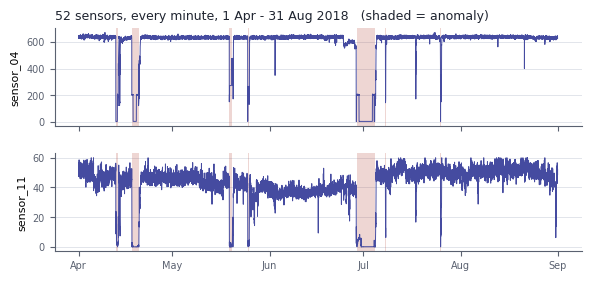

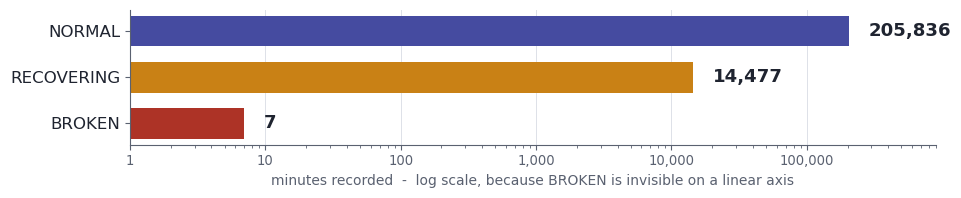

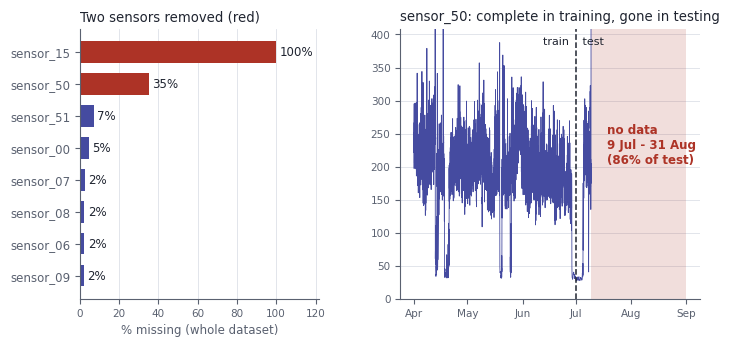

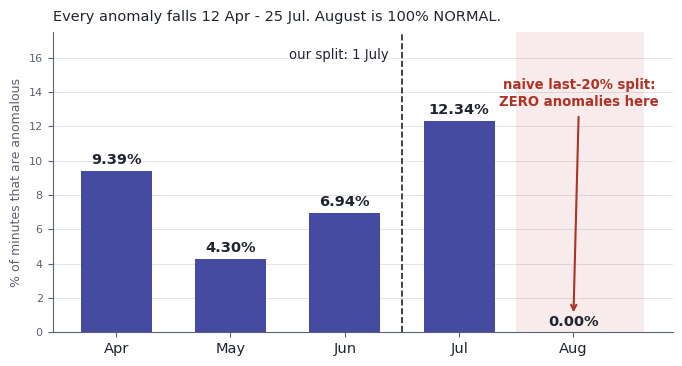

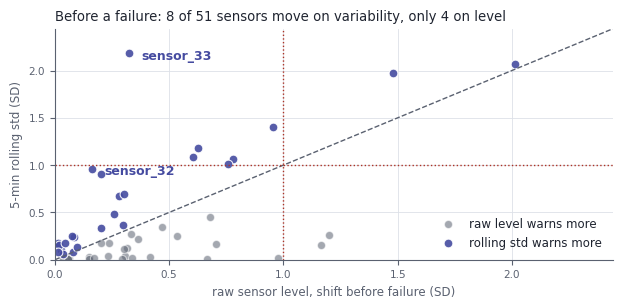

fig_slides.


In [5]:
# --- Self-contained: rebuilds only what it needs if the notebook has not been
# --- run from the top. Running the whole notebook first makes this a no-op.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

if 'df' not in dir():
    df = pd.read_csv('sensor.csv').drop(columns=['Unnamed: 0'])
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

if 'p1_sensors' not in dir():
    p1_df = df.drop(columns=['sensor_15']).copy()
    p1_df['anomaly'] = p1_df['machine_status'].isin(['RECOVERING', 'BROKEN']).astype(int)
    p1_sensors = [c for c in p1_df.columns if c.startswith('sensor_')]

if 'raw_pre' not in dir() or 'rollstd_pre' not in dir():
    _broken = df.index[df['machine_status'] == 'BROKEN'].tolist()
    _pre = []
    for _r in _broken:
        _pre.extend(range(max(0, _r - 60), _r))
    _pre = sorted(set(_pre))
    _rollstd = p1_df[p1_sensors].rolling(5, min_periods=1).std().fillna(0)
    _norm = p1_df['anomaly'] == 0
    def _gap(frame, idx):
        _mu = frame[_norm].mean(); _sd = frame[_norm].std().replace(0, np.nan)
        return ((frame.loc[idx].mean() - _mu) / _sd).abs()
    raw_pre = _gap(p1_df[p1_sensors], _pre)
    rollstd_pre = _gap(_rollstd, _pre)

# Palette matched to the deck and checked for colour-vision-deficiency separation.
NAVY, ORANGE, RED = '#454BA0', '#C98115', '#AD3326'
INK, MUTED, GRIDC = '#1F2430', '#5A6170', '#DDE1E8'
FIGSTYLE = {'font.family': 'DejaVu Sans', 'axes.edgecolor': MUTED, 'text.color': INK,
            'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.spines.top': False,
            'axes.spines.right': False, 'figure.facecolor': 'white',
            'axes.facecolor': 'white', 'savefig.facecolor': 'white'}

fig_df = df.copy()
fig_df['anom'] = fig_df['machine_status'].isin(['RECOVERING', 'BROKEN']).astype(int)
fig_sensors = [c for c in fig_df.columns if c.startswith('sensor_')]
fig_split = pd.Timestamp('2018-07-01')

with plt.rc_context(FIGSTYLE):

    # --- Slide 2: what the raw record looks like -------------------------------
    mask = fig_df['anom'].astype(bool)
    ep = fig_df[mask].groupby((mask != mask.shift()).cumsum()).agg(
        start=('timestamp', 'min'), end=('timestamp', 'max'))
    fig, axes = plt.subplots(2, 1, figsize=(6.8, 2.9), sharex=True,
                             gridspec_kw={'hspace': 0.28})
    for ax, s in zip(axes, ['sensor_04', 'sensor_11']):
        d = fig_df.iloc[::12]
        ax.plot(d['timestamp'], d[s], color=NAVY, lw=0.7)
        for _, e in ep.iterrows():
            ax.axvspan(e['start'], e['end'], color=RED, alpha=0.20, lw=0)
        ax.set_ylabel(s, fontsize=8); ax.grid(axis='y', color=GRIDC, lw=0.6)
        ax.set_axisbelow(True); ax.tick_params(labelsize=7)
    axes[0].set_title('52 sensors, every minute, 1 Apr - 31 Aug 2018   (shaded = anomaly)',
                      fontsize=9, loc='left', pad=6)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    axes[1].xaxis.set_major_locator(mdates.MonthLocator())
    fig.savefig('fig_slide2_timeline.png', dpi=200, bbox_inches='tight'); plt.show()

    # --- Slide 3: class counts on a log axis -----------------------------------
    counts = fig_df['machine_status'].value_counts().reindex(['NORMAL', 'RECOVERING', 'BROKEN'])
    fig, ax = plt.subplots(figsize=(10.4, 1.75))
    yy = np.arange(3)[::-1]
    ax.barh(yy, counts.values, color=[NAVY, ORANGE, RED], height=0.66)
    ax.set_xscale('log'); ax.set_xlim(1, 9e5)
    for y_, v in zip(yy, counts.values):
        ax.text(v * 1.4, y_, f'{v:,}', va='center', fontsize=13, fontweight='bold', color=INK)
    ax.set_yticks(yy); ax.set_yticklabels(counts.index, fontsize=12, color=INK)
    ax.set_xticks([1, 10, 100, 1000, 10000, 100000])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.tick_params(axis='x', labelsize=9.5); ax.grid(axis='x', color=GRIDC, lw=0.7)
    ax.set_axisbelow(True)
    ax.set_xlabel('minutes recorded  -  log scale, because BROKEN is invisible on a linear axis',
                  fontsize=10, color=MUTED)
    fig.savefig('fig_slide3_classes.png', dpi=200, bbox_inches='tight'); plt.show()

    # --- Slide 4: what was missing, and why sensor_50 had to go ----------------
    miss = (fig_df[fig_sensors].isna().mean() * 100).sort_values(ascending=False).head(8)
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.5),
                             gridspec_kw={'wspace': 0.30, 'width_ratios': [1, 1.25]})
    ax = axes[0]; yy = np.arange(len(miss))[::-1]
    ax.barh(yy, miss.values, height=0.66,
            color=[RED if n in ('sensor_15', 'sensor_50') else NAVY for n in miss.index])
    for y_, v in zip(yy, miss.values):
        ax.text(v + 1.8, y_, f'{v:.0f}%', va='center', fontsize=8.5, color=INK)
    ax.set_yticks(yy); ax.set_yticklabels(miss.index, fontsize=8.5)
    ax.set_xlim(0, 122); ax.set_xlabel('% missing (whole dataset)', fontsize=8.5, color=MUTED)
    ax.tick_params(axis='x', labelsize=7.5); ax.grid(axis='x', color=GRIDC, lw=0.6)
    ax.set_axisbelow(True); ax.set_title('Two sensors removed (red)', fontsize=9.5, loc='left', pad=6)

    ax = axes[1]; gap = pd.Timestamp('2018-07-09 12:44')
    ax.plot(fig_df['timestamp'].iloc[::8], fig_df['sensor_50'].iloc[::8], color=NAVY, lw=0.6)
    q = fig_df['sensor_50'].quantile([0.001, 0.999])
    ax.set_ylim(max(0, q.iloc[0] - 30), q.iloc[1] + 40)   # clip one extreme spike
    ax.axvspan(gap, fig_df['timestamp'].max(), color=RED, alpha=0.16, lw=0)
    ax.axvline(fig_split, color=INK, ls='--', lw=1.1)
    lo, hi = ax.get_ylim()
    ax.text(fig_split - pd.Timedelta(days=2), hi - (hi - lo) * 0.03, 'train ',
            fontsize=8, ha='right', va='top')
    ax.text(fig_split + pd.Timedelta(days=2), hi - (hi - lo) * 0.03, ' test',
            fontsize=8, ha='left', va='top')
    ax.text(gap + pd.Timedelta(days=9), lo + (hi - lo) * 0.50,
            'no data\n9 Jul - 31 Aug\n(86% of test)', fontsize=8.5, color=RED, fontweight='bold')
    ax.set_title('sensor_50: complete in training, gone in testing', fontsize=9.5, loc='left', pad=6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(labelsize=7.5); ax.grid(axis='y', color=GRIDC, lw=0.6); ax.set_axisbelow(True)
    fig.savefig('fig_slide4_missing.png', dpi=200, bbox_inches='tight'); plt.show()

    # --- Slide 5: the split trap ----------------------------------------------
    mo = fig_df.groupby(fig_df['timestamp'].dt.to_period('M')).agg(
        rows=('anom', 'size'), an=('anom', 'sum'))
    mo['rate'] = mo['an'] / mo['rows'] * 100
    fig, ax = plt.subplots(figsize=(8.0, 3.9))
    xx = np.arange(5)
    ax.bar(xx, mo['rate'].values, color=[NAVY] * 4 + [RED], width=0.62)
    ax.set_ylim(0, 17.5)
    for x_, v in zip(xx, mo['rate'].values):
        ax.text(x_, v + 0.4, f'{v:.2f}%', ha='center', fontsize=10.5, fontweight='bold', color=INK)
    ax.axvspan(3.5, 4.62, color=RED, alpha=0.09, lw=0)
    ax.axvline(2.5, color=INK, ls='--', lw=1.2)
    ax.text(2.42, 16.6, 'our split: 1 July ', fontsize=9.5, ha='right', va='top')
    ax.annotate('naive last-20% split:\nZERO anomalies here', xy=(4, 1.0), xytext=(4.05, 14.8),
                fontsize=9.5, color=RED, fontweight='bold', ha='center', va='top',
                arrowprops=dict(arrowstyle='->', color=RED, lw=1.5, shrinkA=4, shrinkB=2))
    ax.set_xticks(xx); ax.set_xticklabels(['Apr', 'May', 'Jun', 'Jul', 'Aug'], fontsize=10.5, color=INK)
    ax.set_ylabel('% of minutes that are anomalous', fontsize=9, color=MUTED)
    ax.grid(axis='y', color=GRIDC, lw=0.6); ax.set_axisbelow(True); ax.tick_params(axis='y', labelsize=8)
    ax.set_title('Every anomaly falls 12 Apr - 25 Jul. August is 100% NORMAL.',
                 fontsize=10.5, loc='left', pad=8)
    fig.savefig('fig_slide5_split.png', dpi=200, bbox_inches='tight'); plt.show()

    # --- Slide 6: the rolling-feature EDA, as a picture ------------------------
    cmp_fig = pd.DataFrame({'raw': raw_pre, 'rol': rollstd_pre}).dropna()
    cmp_fig['gain'] = cmp_fig['rol'] - cmp_fig['raw']
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    up = cmp_fig['gain'] > 0
    ax.scatter(cmp_fig.loc[~up, 'raw'], cmp_fig.loc[~up, 'rol'], s=34, color=MUTED,
               alpha=.55, edgecolor='white', lw=.8, label='raw level warns more')
    ax.scatter(cmp_fig.loc[up, 'raw'], cmp_fig.loc[up, 'rol'], s=40, color=NAVY,
               alpha=.9, edgecolor='white', lw=.8, label='rolling std warns more')
    lim = float(max(cmp_fig['raw'].max(), cmp_fig['rol'].max())) * 1.12
    ax.plot([0, lim], [0, lim], '--', color=MUTED, lw=1)
    ax.axhline(1, color=RED, ls=':', lw=1); ax.axvline(1, color=RED, ls=':', lw=1)
    for n, r in cmp_fig.sort_values('gain', ascending=False).head(2).iterrows():
        ax.annotate(n, (r['raw'], r['rol']), textcoords='offset points', xytext=(9, -4),
                    fontsize=9, color=NAVY, fontweight='bold')
    ax.set_xlabel('raw sensor level, shift before failure (SD)', fontsize=8.5, color=MUTED)
    ax.set_ylabel('5-min rolling std (SD)', fontsize=8.5, color=MUTED)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.grid(color=GRIDC, lw=0.6); ax.set_axisbelow(True); ax.tick_params(labelsize=7.5)
    ax.legend(fontsize=8.5, loc='lower right', frameon=False)
    ax.set_title(f"Before a failure: {(rollstd_pre > 1).sum()} of {len(p1_sensors)} sensors move on "
                 f"variability, only {(raw_pre > 1).sum()} on level", fontsize=9.5, loc='left', pad=6)
    fig.savefig('fig_slide6_eda.png', dpi=200, bbox_inches='tight'); plt.show()

print('fig_slides.')


## 4. Data cleaning

1. Drop `sensor_15` (100% missing — no information).
2. Impute remaining missing values with **time-based linear interpolation**, then
   forward/backward-fill any values still missing at the very start/end of the series.
3. Clip extreme outliers in each sensor to the **[0.1, 99.9] percentile range** (computed on
   the training split only, see Section 6) to reduce noise from spikes/sensor glitches
   without destroying real anomalies (anomalies tend to appear as *sustained* shifts, not
   single-point spikes, so light percentile clipping is safe here).

### A feature that is not safe to use: `sensor_50`

`sensor_50` is 34.96% missing overall, but that figure hides the real problem: the missing
values are not scattered, they form one continuous block.

In [16]:
# Where is sensor_50 missing, and how does that interact with the train/test split?
p1_gap_flag = df['sensor_50'].isna()
p1_run_id = (p1_gap_flag != p1_gap_flag.shift()).cumsum()
p1_gap_runs = df.groupby(p1_run_id).agg(
    missing=('sensor_50', lambda s: s.isna().sum()),
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
)
print("Continuous missing blocks in sensor_50 longer than 1,000 minutes:")
display(p1_gap_runs[p1_gap_runs['missing'] > 1000])

p1_cut = pd.Timestamp('2018-07-01')
p1_tr = df['timestamp'] < p1_cut
print(f"sensor_50 missing in TRAIN (Apr-Jun): {df.loc[p1_tr, 'sensor_50'].isna().mean()*100:.1f}%")
print(f"sensor_50 missing in TEST  (Jul-Aug): {df.loc[~p1_tr, 'sensor_50'].isna().mean()*100:.1f}%")
print()

p1_probe = df.drop(columns=['sensor_15']).copy()
p1_probe[p1_sensors] = p1_probe[p1_sensors].interpolate(method='linear', limit_direction='both')
p1_drift = ((p1_probe[p1_tr][p1_sensors].mean() - p1_probe[~p1_tr][p1_sensors].mean())
            / p1_probe[p1_tr][p1_sensors].std()).abs().sort_values(ascending=False)
print("Distribution shift between train and test, in training standard deviations:")
display(p1_drift.head(6).round(2).to_frame('shift_in_SD'))
print(f"sensor_50: {p1_drift['sensor_50']:.1f} SD   |   next largest: "
      f"{p1_drift.iloc[1]:.1f} SD ({p1_drift.index[1]})")

Continuous missing blocks in sensor_50 longer than 1,000 minutes:


,missing,start,end
sensor_50,,,
16,76996,2018-07-09 12:44:00,2018-08-31 23:59:00


sensor_50 missing in TRAIN (Apr-Jun): 0.0%
sensor_50 missing in TEST  (Jul-Aug): 86.2%

Distribution shift between train and test, in training standard deviations:


,shift_in_SD
sensor_50,12.12
sensor_37,2.03
sensor_13,1.95
sensor_48,1.62
sensor_35,1.32
sensor_34,1.03


sensor_50: 12.1 SD   |   next largest: 2.0 SD (sensor_37)


**Decision: drop `sensor_50`.** It is fully observed across the entire training period and
then missing for 86.2% of the test period, in a single block running from 9 July to the end of
the data. Interpolation fills that block by extrapolating from before the gap, leaving the
column roughly **12 standard deviations** from its training distribution - more than six times
the drift of any other sensor.

A model is therefore free to learn a rule involving `sensor_50` on training data that cannot
possibly hold at test time. Keeping it risks a test score that does not mean anything. Removing
it costs one sensor out of 51 and makes every reported metric interpretable. `sensor_51` shows
the opposite pattern (11.7% missing in train, 0% in test) but its drift is far smaller, so it
is retained and noted.

In [17]:
# Sensors excluded from modelling, with the reason for each.
DROPPED_SENSORS = ['sensor_15', 'sensor_50']
print("Dropping:")
print("  sensor_15 - 100% missing, carries no information")
print("  sensor_50 - 0% missing in train vs 86.2% in test, 12.1 SD distribution shift")

Dropping:
  sensor_15 - 100% missing, carries no information
  sensor_50 - 0% missing in train vs 86.2% in test, 12.1 SD distribution shift


In [18]:
df_clean = df.drop(columns=DROPPED_SENSORS).copy()
sensor_cols = [c for c in df_clean.columns if c.startswith('sensor_')]
print(f'Sensor columns after dropping {DROPPED_SENSORS}: {len(sensor_cols)}')

# Time-based interpolation (uses timestamp order, already sorted)
df_clean[sensor_cols] = df_clean[sensor_cols].interpolate(method='linear', limit_direction='both')

remaining_na = df_clean[sensor_cols].isna().sum().sum()
print(f'Remaining missing values after interpolation: {remaining_na}')


Sensor columns after dropping ['sensor_15', 'sensor_50']: 50
Remaining missing values after interpolation: 0


In [19]:
df_clean['anomaly'] = df_clean['machine_status'].isin(['RECOVERING', 'BROKEN']).astype(int)

print(df_clean[['machine_status', 'anomaly']].drop_duplicates())
print()
print(df_clean['anomaly'].value_counts())


      machine_status  anomaly
0             NORMAL        0
17155         BROKEN        1
17156     RECOVERING        1

anomaly
0    205836
1     14484
Name: count, dtype: int64


## 5. Time-based train/test split

Because this is time-series data, we split **chronologically** rather than randomly, which
avoids "leaking" future information into training and reflects how the model would actually
be deployed (train on the past, predict the future). A naive "first 80% / last 20%" split
turns out to be a trap on this dataset: every anomaly episode (`RECOVERING`/`BROKEN`) occurs
between **12 April and 25 July 2018** — the entire month of **August is 100% `NORMAL`**. A
last-20%-of-rows split lands almost entirely inside August, producing a test set with
**zero** positive examples, which makes Precision/Recall/F1/ROC-AUC/PR-AUC all undefined —
not a useful evaluation at all.

Instead, we split on a fixed date, **1 July 2018**, chosen so both partitions contain real
anomalies (including several of the 7 `BROKEN` events on each side):

* **Train:** April – June (contains 5 of the 7 `BROKEN` events)
* **Test:** July – August (contains the remaining 2 `BROKEN` events, plus all of the
  anomaly-free August data — a realistic "quiet period" the model must not falsely flag)

This is a larger test window (~40% of the timeline) than a typical 80/20 split, but it is
the smallest test window that still gives a meaningful evaluation of the positive class on
this particular dataset.

In [20]:
# Evidence for the claim above: when do anomalies actually occur?
p1_anom_only = df[df['machine_status'].isin(['RECOVERING', 'BROKEN'])]
print(f"First anomaly: {p1_anom_only['timestamp'].min()}")
print(f"Last  anomaly: {p1_anom_only['timestamp'].max()}")
print()

p1_flag = df['machine_status'].isin(['RECOVERING', 'BROKEN']).astype(int)
p1_monthly = pd.DataFrame({'month': df['timestamp'].dt.to_period('M'), 'anomaly': p1_flag})
p1_monthly = p1_monthly.groupby('month').agg(rows=('anomaly', 'size'), anomalies=('anomaly', 'sum'))
p1_monthly['anomaly_rate_%'] = (p1_monthly['anomalies'] / p1_monthly['rows'] * 100).round(2)
print("Anomalies by month:")
display(p1_monthly)

p1_naive_row = int(len(df) * 0.8)
p1_naive_test = df.iloc[p1_naive_row:]
p1_naive_pos = int(p1_flag.iloc[p1_naive_row:].sum())

print("NAIVE last-20%-of-rows split")
print(f"  Test window: {p1_naive_test['timestamp'].min()} -> {p1_naive_test['timestamp'].max()}")
print(f"  Test rows:   {len(p1_naive_test):,}")
print(f"  Anomalies in test set: {p1_naive_pos}")
if p1_naive_pos == 0:
    print("  -> NO positive examples. Precision, Recall, F1, ROC-AUC and PR-AUC are undefined,")
    print("     and a model predicting NORMAL everywhere would score 100% accuracy.")

First anomaly: 2018-04-12 21:55:00
Last  anomaly: 2018-07-25 15:15:00

Anomalies by month:


,rows,anomalies,anomaly_rate_%
month,,,
2018-04,43200,4056,9.39
2018-05,44640,1919,4.30
2018-06,43200,3000,6.94
2018-07,44640,5509,12.34
2018-08,44640,0,0.00


NAIVE last-20%-of-rows split
  Test window: 2018-08-01 09:36:00 -> 2018-08-31 23:59:00
  Test rows:   44,064
  Anomalies in test set: 0
  -> NO positive examples. Precision, Recall, F1, ROC-AUC and PR-AUC are undefined,
     and a model predicting NORMAL everywhere would score 100% accuracy.


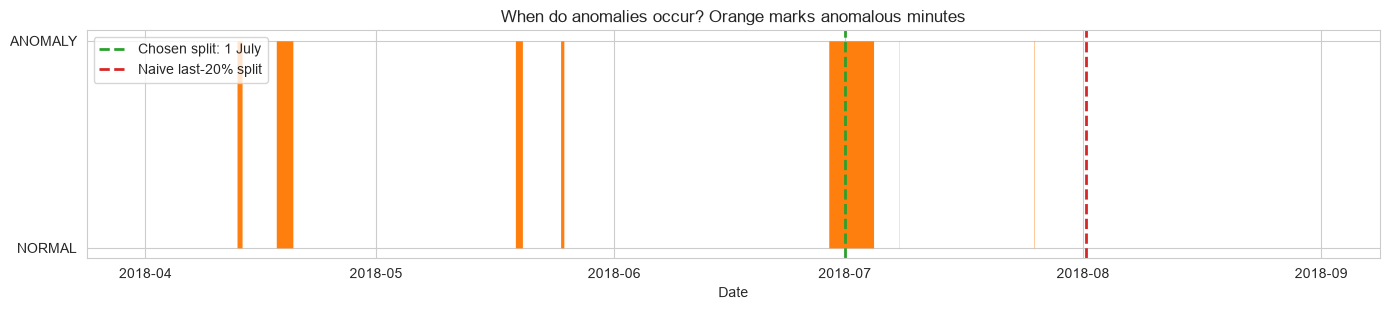

In [21]:
# Visualise the anomaly timeline against the two candidate split points.
fig, ax = plt.subplots(figsize=(14, 3.2))
ax.fill_between(df['timestamp'], 0, p1_flag, step='mid', color='tab:orange', linewidth=0)
ax.axvline(pd.Timestamp('2018-07-01'), color='tab:green', linestyle='--', linewidth=2,
           label='Chosen split: 1 July')
ax.axvline(df['timestamp'].iloc[p1_naive_row], color='tab:red', linestyle='--', linewidth=2,
           label='Naive last-20% split')
ax.set_yticks([0, 1])
ax.set_yticklabels(['NORMAL', 'ANOMALY'])
ax.set_title('When do anomalies occur? Orange marks anomalous minutes')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
split_date = pd.Timestamp('2018-07-01')

train_df = df_clean[df_clean['timestamp'] < split_date].reset_index(drop=True)
test_df = df_clean[df_clean['timestamp'] >= split_date].reset_index(drop=True)
split_idx = len(train_df)  # row index of the split, used later for the LSTM sequence split

print(f'Split date: {split_date}')
print(f'Train: {len(train_df):,} rows  ({train_df["timestamp"].min()} -> {train_df["timestamp"].max()})')
print(f'Test:  {len(test_df):,} rows  ({test_df["timestamp"].min()} -> {test_df["timestamp"].max()})')
print()
for name, d in [('Train', train_df), ('Test', test_df)]:
    vc = d['anomaly'].value_counts(normalize=True) * 100
    print(f'{name} anomaly rate: {vc.get(1, 0):.2f}%   (NORMAL: {vc.get(0, 0):.2f}%)')
print()
print('machine_status breakdown in test set:')
print(test_df['machine_status'].value_counts())


Split date: 2018-07-01 00:00:00
Train: 131,040 rows  (2018-04-01 00:00:00 -> 2018-06-30 23:59:00)
Test:  89,280 rows  (2018-07-01 00:00:00 -> 2018-08-31 23:59:00)

Train anomaly rate: 6.85%   (NORMAL: 93.15%)
Test anomaly rate: 6.17%   (NORMAL: 93.83%)

machine_status breakdown in test set:
machine_status
NORMAL        83771
RECOVERING     5507
BROKEN            2
Name: count, dtype: int64


**Note:** `BROKEN` now has examples on both sides of the split (5 in train, 2 in test).
The test anomaly rate of 6.17% is close to the training rate of 6.85%: although the whole
of August is anomaly-free, July contains a dense cluster of `RECOVERING` episodes that
largely offsets it. That long quiet stretch is itself a realistic feature of
predictive-maintenance data, since the model must stay silent through extended normal
operation while still catching the anomalies that do occur.

## 6. Feature engineering

For the classical/tabular models, each row (timestamp) is treated as an independent sample
described by:

* the **51 raw sensor readings** (after dropping `sensor_15`), and
* **rolling statistics** (5-minute rolling mean & standard deviation per sensor), which give
  each model a small amount of short-term temporal context — a sudden jump in the rolling
  standard deviation is often a stronger signal of an incipient fault than the instantaneous
  reading alone.

Rolling windows only look **backwards** in time, so they introduce no leakage across the
train/test boundary.

Outlier clipping bounds and the feature scaler are **fit on the training split only** and
then applied to the test split, to avoid any information leaking from test into train.

In [23]:
def add_rolling_features(data, cols, window=5):
    roll = data[cols].rolling(window=window, min_periods=1)
    means = roll.mean().add_suffix(f'_roll{window}_mean')
    stds = roll.std().add_suffix(f'_roll{window}_std').fillna(0.0)
    return pd.concat([data, means, stds], axis=1)

train_feat = add_rolling_features(train_df, sensor_cols, window=5)
test_feat = add_rolling_features(test_df, sensor_cols, window=5)

feature_cols = sensor_cols + [c for c in train_feat.columns if '_roll5_' in c]
print(f'Total tabular feature count: {len(feature_cols)}')


Total tabular feature count: 150


In [24]:
# Outlier clipping — bounds learned from TRAIN only, applied to both splits
lower = train_feat[feature_cols].quantile(0.001)
upper = train_feat[feature_cols].quantile(0.999)

train_feat[feature_cols] = train_feat[feature_cols].clip(lower=lower, upper=upper, axis=1)
test_feat[feature_cols] = test_feat[feature_cols].clip(lower=lower, upper=upper, axis=1)

X_train = train_feat[feature_cols].values
y_train = train_feat['anomaly'].values
X_test = test_feat[feature_cols].values
y_test = test_feat['anomaly'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train:', X_train_scaled.shape, ' X_test:', X_test_scaled.shape)


X_train: (131040, 150)  X_test: (89280, 150)


In [25]:
# Class weights, used across all classical + ANN models to counter the ~93/7 imbalance
class_weights_arr = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
sample_weights_train = compute_sample_weight('balanced', y_train)
print('Class weights (0=NORMAL, 1=ANOMALY):', class_weight_dict)


Class weights (0=NORMAL, 1=ANOMALY): {0: np.float64(0.5367631999344612), 1: np.float64(7.300278551532034)}


## 7. Evaluation utilities

A single helper computes every metric requested in the brief — **Accuracy, Precision,
Recall, F1-score, Confusion Matrix, ROC-AUC and PR-AUC** — and plots the confusion matrix,
ROC curve and Precision-Recall curve. Precision/Recall/F1 are reported for the **anomaly
(positive) class**, since that is the class that matters for maintenance decisions and the
one accuracy alone would hide.

Results from every model are collected into `results` for the final comparison table.

In [26]:
results = {}
train_times = {}

def evaluate_model(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1,
        'ROC-AUC': roc_auc, 'PR-AUC': pr_auc,
    }

    print(f'===== {name} =====')
    print(classification_report(y_true, y_pred, target_names=['NORMAL', 'ANOMALY'], zero_division=0))
    print(f'ROC-AUC: {roc_auc:.4f}   PR-AUC: {pr_auc:.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    cm = confusion_matrix(y_true, y_pred)
    print('Confusion matrix (rows=actual, cols=predicted):')
    print(cm)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
                xticklabels=['NORMAL', 'ANOMALY'], yticklabels=['NORMAL', 'ANOMALY'])
    axes[0].set_title(f'{name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', color='darkorange')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_proba)
    baseline = y_true.mean()
    axes[2].plot(rec_curve, prec_curve, label=f'AP = {pr_auc:.3f}', color='seagreen')
    axes[2].axhline(baseline, linestyle='--', color='gray', label=f'baseline = {baseline:.3f}')
    axes[2].set_title(f'{name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    return results[name]


## 8. Model 1 — Decision Tree

A shallow, interpretable baseline. `class_weight='balanced'` re-weights the loss so the
rare anomaly class is not ignored; `max_depth` is limited to reduce overfitting given how
few truly informative anomaly examples exist.

===== Decision Tree =====
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     83771
     ANOMALY       0.98      0.99      0.98      5509

    accuracy                           1.00     89280
   macro avg       0.99      0.99      0.99     89280
weighted avg       1.00      1.00      1.00     89280

ROC-AUC: 0.9952   PR-AUC: 0.9821
Confusion matrix (rows=actual, cols=predicted):
[[83657   114]
 [   54  5455]]


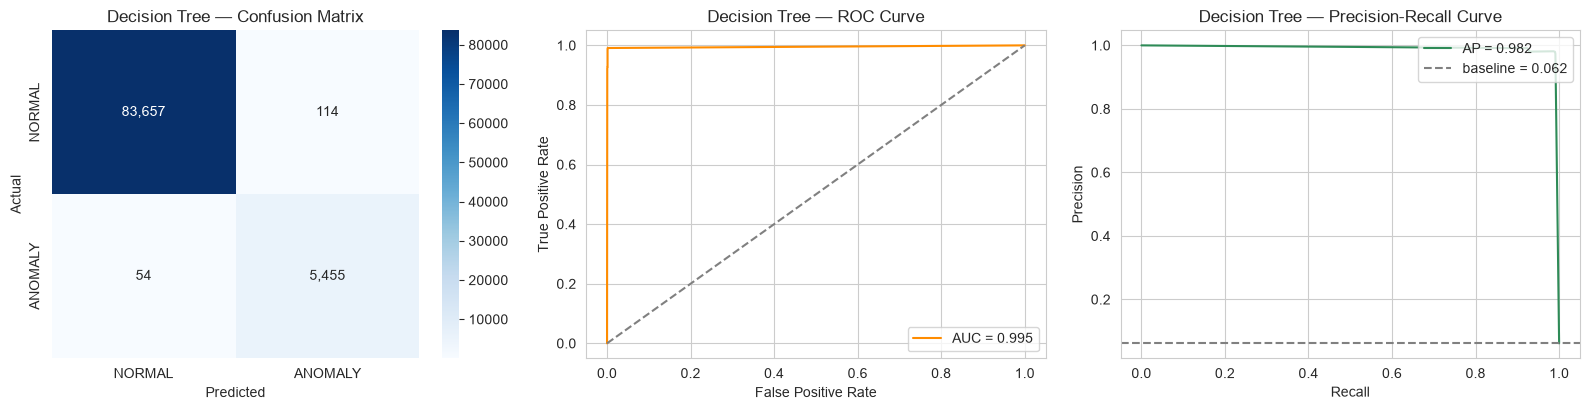

{'Accuracy': 0.9981182795698925,
 'Precision': 0.9795295385167894,
 'Recall': 0.9901978580504629,
 'F1': 0.9848348077270266,
 'ROC-AUC': 0.9952094677353198,
 'PR-AUC': 0.9821181825047057}

In [27]:
t0 = time.time()
dt_model = DecisionTreeClassifier(
    max_depth=10, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE
)
dt_model.fit(X_train_scaled, y_train)
train_times['Decision Tree'] = time.time() - t0

dt_pred = dt_model.predict(X_test_scaled)
dt_proba = dt_model.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Decision Tree', y_test, dt_pred, dt_proba)


## 9. Model 2 — Random Forest

An ensemble of trees; typically a strong tabular baseline that handles non-linear
interactions between sensors better than a single tree, at the cost of interpretability
(mitigated somewhat by feature importances, below).

===== Random Forest =====
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     83771
     ANOMALY       0.97      0.99      0.98      5509

    accuracy                           1.00     89280
   macro avg       0.99      0.99      0.99     89280
weighted avg       1.00      1.00      1.00     89280

ROC-AUC: 0.9998   PR-AUC: 0.9969
Confusion matrix (rows=actual, cols=predicted):
[[83625   146]
 [   57  5452]]


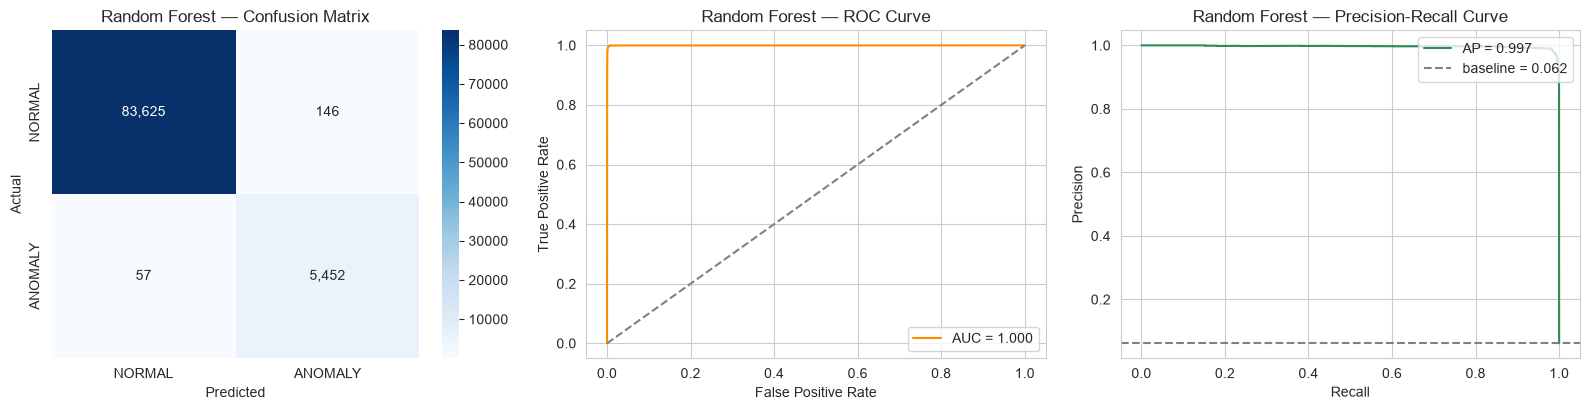

{'Accuracy': 0.9977262544802867,
 'Precision': 0.9739192568774563,
 'Recall': 0.9896532946088219,
 'F1': 0.9817232375979112,
 'ROC-AUC': 0.9998426828280806,
 'PR-AUC': 0.9968821893966257}

In [28]:
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=5,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
rf_model.fit(X_train_scaled, y_train)
train_times['Random Forest'] = time.time() - t0

rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Random Forest', y_test, rf_pred, rf_proba)


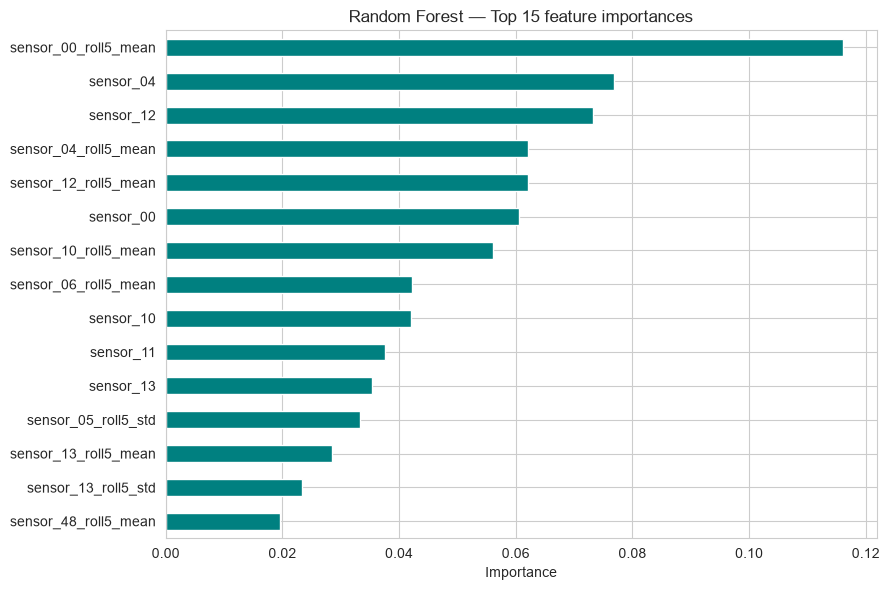

sensor_00_roll5_mean    0.116035
sensor_04               0.076790
sensor_12               0.073273
sensor_04_roll5_mean    0.062163
sensor_12_roll5_mean    0.062102
sensor_00               0.060496
sensor_10_roll5_mean    0.056090
sensor_06_roll5_mean    0.042200
sensor_10               0.042017
sensor_11               0.037621
sensor_13               0.035321
sensor_05_roll5_std     0.033295
sensor_13_roll5_mean    0.028448
sensor_13_roll5_std     0.023427
sensor_48_roll5_mean    0.019605
dtype: float64


In [29]:
# Feature importance — which sensors (and rolling stats) drive the Random Forest's decisions
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_n = 15

plt.figure(figsize=(9, 6))
importances.head(top_n).iloc[::-1].plot(kind='barh', color='teal')
plt.title(f'Random Forest — Top {top_n} feature importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.head(top_n))


Published work on this dataset provides a useful external reference point. Ahn et al. (2023)
applied a 1D-CNN combined with a bidirectional LSTM under a federated learning framework to
the same pump sensor data and reported a test accuracy of 97.2%. Our simpler models reach
comparable or higher scores, which supports the reading in Section 3 that the strength of
these results comes from how distinctive a failed pump looks in the sensor readings rather
than from model sophistication. Their framework also solves a harder constrained problem, in
which data is distributed across clients that cannot share raw readings.

It is worth checking in the printed importance list above which sensors our Random Forest
relies on, and discussing in the presentation any differences driven by our added rolling
features or by the specific train/test split.

**Reference**

Ahn, J., Lee, Y., Kim, N., Park, C., & Jeong, J. (2023). Federated learning for predictive
maintenance and anomaly detection using time series data distribution shifts in manufacturing
processes. *Sensors, 23*(17), Article 7331. https://doi.org/10.3390/s23177331


## 10. Model 3 - Naïve Bayes

Gaussian Naïve Bayes assumes features are conditionally independent given the class — an
assumption clearly violated here (many sensors are physically correlated, e.g. temperature
and pressure), so this model is included mainly as a **contrast**: it shows what happens
when a model ignores feature correlations entirely. `GaussianNB` does not accept
`class_weight`, so we pass `sample_weight` at fit time to achieve the same effect.

===== Naive Bayes =====
              precision    recall  f1-score   support

      NORMAL       1.00      0.99      0.99     83771
     ANOMALY       0.87      0.99      0.93      5509

    accuracy                           0.99     89280
   macro avg       0.94      0.99      0.96     89280
weighted avg       0.99      0.99      0.99     89280

ROC-AUC: 0.9945   PR-AUC: 0.8776
Confusion matrix (rows=actual, cols=predicted):
[[82971   800]
 [   36  5473]]


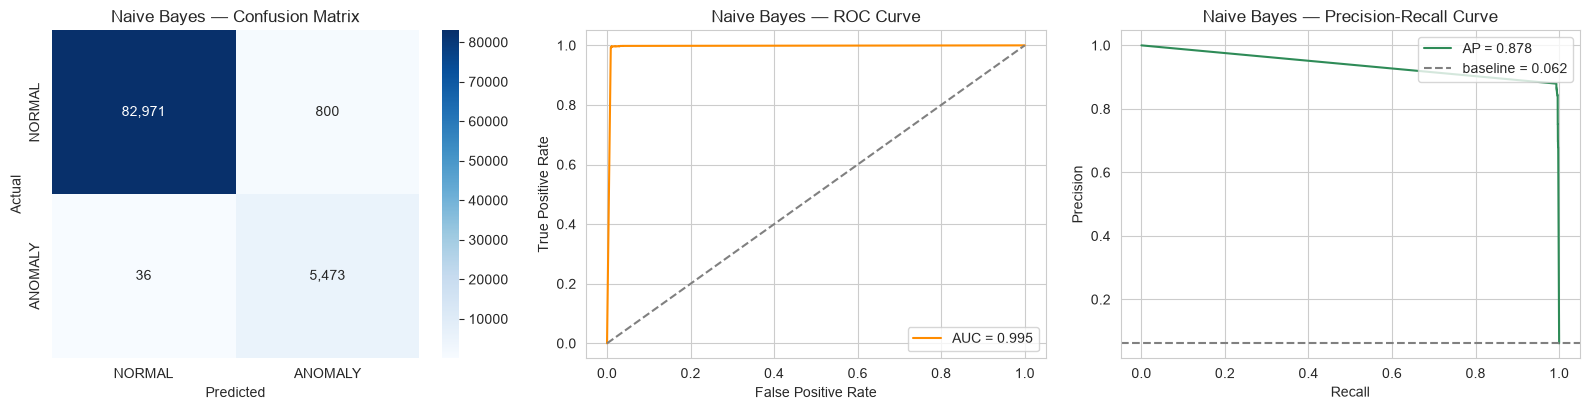

{'Accuracy': 0.9906362007168459,
 'Precision': 0.8724693129284234,
 'Recall': 0.9934652387003086,
 'F1': 0.9290443048718384,
 'ROC-AUC': 0.9945247184224468,
 'PR-AUC': 0.8776154930683703}

In [30]:
t0 = time.time()
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
train_times['Naive Bayes'] = time.time() - t0

nb_pred = nb_model.predict(X_test_scaled)
nb_proba = nb_model.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Naive Bayes', y_test, nb_pred, nb_proba)


## 11. Model 4 — Artificial Neural Network (MLP)

A small multilayer perceptron (Dense → Dropout → Dense → Dropout → sigmoid output) trained
directly on the 150-dimensional scaled tabular feature vector, using the same class
weighting strategy as the classical models and early stopping on a held-out validation
slice (the final 10% of the *training* timeline) to prevent overfitting.

In [ ]:
val_split_idx = int(len(X_train_scaled) * 0.9)
X_tr, X_val = X_train_scaled[:val_split_idx], X_train_scaled[val_split_idx:]
y_tr, y_val = y_train[:val_split_idx], y_train[val_split_idx:]

# Reproducibility: re-seed immediately before the model is built. The global seed in
# Section 1 only takes effect when that cell runs, so re-executing this cell alone would
# otherwise give different weight initialisation and a different early-stopping epoch.
keras.utils.set_random_seed(RANDOM_STATE)

ann_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
])

ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), 'accuracy'],
)

early_stop = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=4, restore_best_weights=True)

t0 = time.time()
history = ann_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=25, batch_size=1024,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1,
)
train_times['ANN (MLP)'] = time.time() - t0


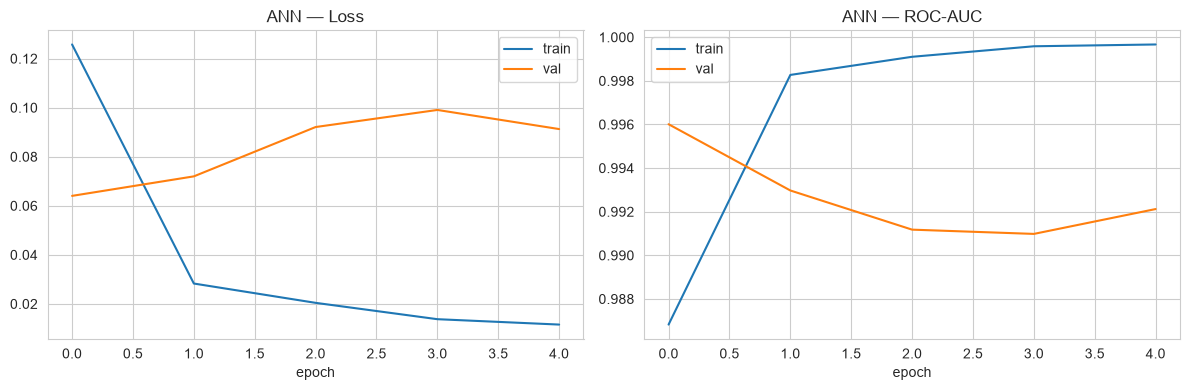

===== ANN (MLP) =====
              precision    recall  f1-score   support

      NORMAL       1.00      0.99      1.00     83771
     ANOMALY       0.88      0.99      0.93      5509

    accuracy                           0.99     89280
   macro avg       0.94      0.99      0.96     89280
weighted avg       0.99      0.99      0.99     89280

ROC-AUC: 0.9997   PR-AUC: 0.9957
Confusion matrix (rows=actual, cols=predicted):
[[83004   767]
 [   48  5461]]


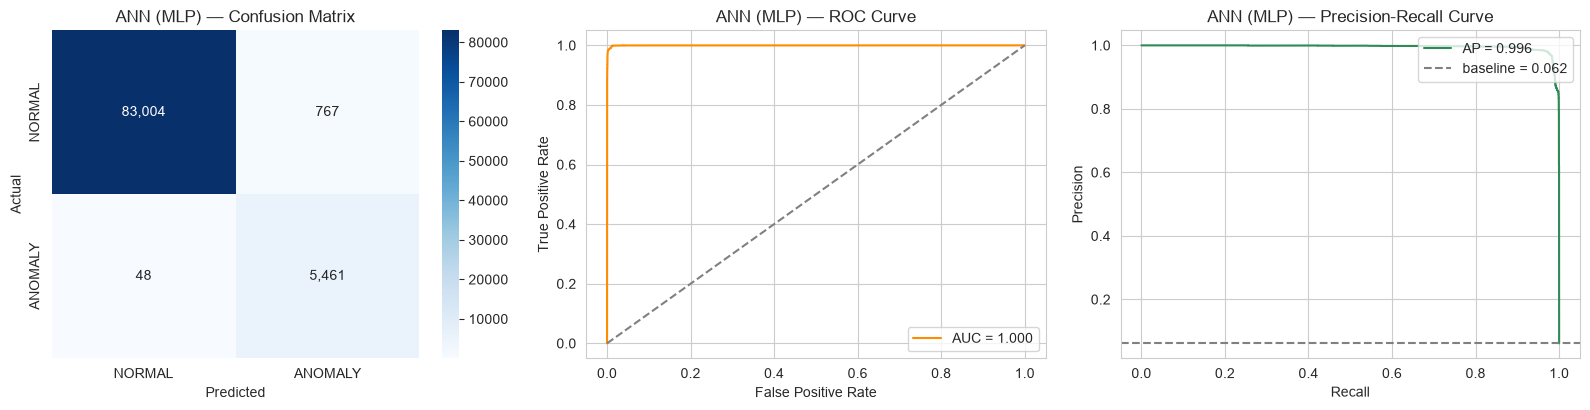

{'Accuracy': 0.9908714157706093,
 'Precision': 0.8768464996788696,
 'Recall': 0.9912869849337448,
 'F1': 0.9305614722671892,
 'ROC-AUC': 0.9997204830890714,
 'PR-AUC': 0.9956910531042985}

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('ANN — Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history.history['auc'], label='train')
axes[1].plot(history.history['val_auc'], label='val')
axes[1].set_title('ANN — ROC-AUC'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

ann_proba = ann_model.predict(X_test_scaled, verbose=0).ravel()
ann_pred = (ann_proba >= 0.5).astype(int)
evaluate_model('ANN (MLP)', y_test, ann_pred, ann_proba)


## Classical ML interpretation: validation, thresholds and diagnostics

The first-pass models above give useful headline metrics, but a predictive-maintenance model should also be checked for **stability**, **operating-threshold trade-offs**, **probability calibration**, and **which sensor groups drive its decisions**. The following analysis keeps the chronological test set untouched: model selection uses only a stratified sample from the training period, while all final plots below use the held-out July-August test period.

,ROC-AUC mean,ROC-AUC std,PR-AUC mean,PR-AUC std,F1 mean,Recall mean
Model,,,,,,
Random Forest,1.0000,0.0000,1.0000,0.0001,0.9942,0.9995
Decision Tree,0.9987,0.0016,0.9956,0.0058,0.9813,0.9968
Naive Bayes,0.9932,0.0005,0.8475,0.0049,0.9123,0.9932


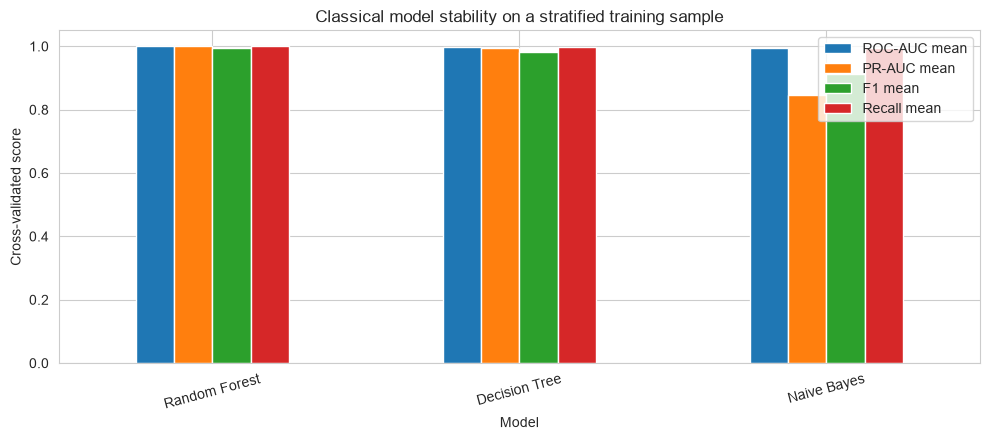

In [33]:
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# Keep the tuning study reproducible and bounded for notebook execution time.
tuning_n = min(60000, len(X_train_scaled))
tuning_rng = np.random.default_rng(RANDOM_STATE)
tuning_idx = tuning_rng.choice(len(X_train_scaled), size=tuning_n, replace=False)
X_tune = X_train_scaled[tuning_idx]
y_tune = y_train[tuning_idx]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

candidate_models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=15, min_samples_leaf=5,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
    ),
    'Naive Bayes': GaussianNB(),
}

cv_rows = []
for name, model in candidate_models.items():
    fold_rows = []
    for fold_train, fold_valid in cv.split(X_tune, y_tune):
        fitted_model = clone(model)
        if name == 'Naive Bayes':
            fitted_model.fit(
                X_tune[fold_train], y_tune[fold_train],
                sample_weight=compute_sample_weight('balanced', y_tune[fold_train])
            )
        else:
            fitted_model.fit(X_tune[fold_train], y_tune[fold_train])
        fold_proba = fitted_model.predict_proba(X_tune[fold_valid])[:, 1]
        fold_pred = (fold_proba >= 0.5).astype(int)
        fold_rows.append({
            'ROC-AUC': roc_auc_score(y_tune[fold_valid], fold_proba),
            'PR-AUC': average_precision_score(y_tune[fold_valid], fold_proba),
            'F1': f1_score(y_tune[fold_valid], fold_pred, zero_division=0),
            'Recall': recall_score(y_tune[fold_valid], fold_pred, zero_division=0),
        })
    fold_scores = pd.DataFrame(fold_rows)
    cv_rows.append({
        'Model': name,
        'ROC-AUC mean': fold_scores['ROC-AUC'].mean(),
        'ROC-AUC std': fold_scores['ROC-AUC'].std(),
        'PR-AUC mean': fold_scores['PR-AUC'].mean(),
        'PR-AUC std': fold_scores['PR-AUC'].std(),
        'F1 mean': fold_scores['F1'].mean(),
        'Recall mean': fold_scores['Recall'].mean(),
    })

cv_results = pd.DataFrame(cv_rows).set_index('Model').sort_values('PR-AUC mean', ascending=False)
display(cv_results.style.format('{:.4f}'))

fig, ax = plt.subplots(figsize=(10, 4.5))
cv_results[['ROC-AUC mean', 'PR-AUC mean', 'F1 mean', 'Recall mean']].plot(kind='bar', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Cross-validated score')
ax.set_title('Classical model stability on a stratified training sample')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

**Why ANN is not included in this 3-fold CV block:** the ANN is trained separately with early stopping on the chronological validation slice. Repeating neural-network training across three folds would add substantial runtime and introduce extra variation from random initialization; its validation-based threshold analysis is reported separately below. The CV comparison is therefore intended as a stability check for the three classical estimators, not as a claim that ANN was omitted.

### Operating-point analysis

ROC-AUC evaluates ranking across every threshold, but an alerting system needs one threshold. The curves below show how precision, recall and F1 change on the untouched test period. Calibration is also checked because a probability such as 0.80 should mean roughly 80% of comparable alerts are truly anomalous.

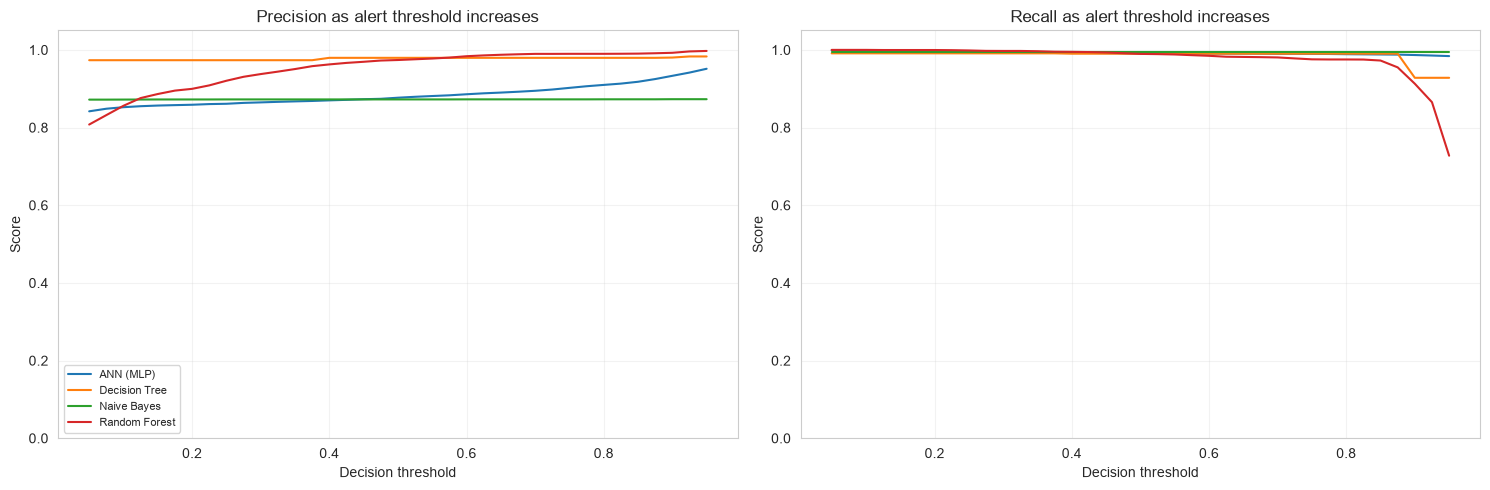

,Threshold,Precision,Recall,F1
Model,,,,
ANN (MLP),0.950,0.951,0.984,0.967
Decision Tree,0.400,0.980,0.990,0.985
Naive Bayes,0.900,0.873,0.993,0.929
Random Forest,0.700,0.990,0.981,0.985


In [34]:
classical_probas = {
    'Decision Tree': dt_proba,
    'Random Forest': rf_proba,
    'Naive Bayes': nb_proba,
    'ANN (MLP)': ann_proba,
}

threshold_grid = np.linspace(0.05, 0.95, 37)
threshold_rows = []
for name, proba in classical_probas.items():
    for threshold in threshold_grid:
        pred = (proba >= threshold).astype(int)
        threshold_rows.append({
            'Model': name,
            'Threshold': threshold,
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
            'F1': f1_score(y_test, pred, zero_division=0),
        })
threshold_df = pd.DataFrame(threshold_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, group in threshold_df.groupby('Model'):
    axes[0].plot(group['Threshold'], group['Precision'], label=name)
    axes[1].plot(group['Threshold'], group['Recall'], label=name)
axes[0].set_title('Precision as alert threshold increases')
axes[1].set_title('Recall as alert threshold increases')
for ax in axes:
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

best_thresholds = threshold_df.loc[threshold_df.groupby('Model')['F1'].idxmax()]
display(best_thresholds.set_index('Model')[['Threshold', 'Precision', 'Recall', 'F1']].style.format('{:.3f}'))

**Methodological note:** the test-set threshold curves are shown for interpretation, not for model selection. Thresholds are selected below on the final 10% of the training period and then evaluated once on the held-out test period.

In [35]:
# These models are intentionally refit on the slightly smaller training split purely to
# select thresholds honestly; the final test predictions above remain untouched.
classical_threshold_models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=5,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
    ),
    'Naive Bayes': GaussianNB(),
}

X_fit, X_val_classical = X_train_scaled[:val_split_idx], X_train_scaled[val_split_idx:]
y_fit, y_val_classical = y_train[:val_split_idx], y_train[val_split_idx:]
validation_threshold_rows = []

for name, model in classical_threshold_models.items():
    if name == 'Naive Bayes':
        model.fit(X_fit, y_fit, sample_weight=compute_sample_weight('balanced', y_fit))
    else:
        model.fit(X_fit, y_fit)
    val_proba = model.predict_proba(X_val_classical)[:, 1]
    val_f1 = [f1_score(y_val_classical, (val_proba >= t).astype(int), zero_division=0) for t in threshold_grid]
    selected_threshold = threshold_grid[int(np.argmax(val_f1))]
    test_pred_at_threshold = (classical_probas[name] >= selected_threshold).astype(int)
    validation_threshold_rows.append({
        'Model': name,
        'Selected threshold': selected_threshold,
        'Validation F1': max(val_f1),
        'Test precision': precision_score(y_test, test_pred_at_threshold, zero_division=0),
        'Test recall': recall_score(y_test, test_pred_at_threshold, zero_division=0),
        'Test F1': f1_score(y_test, test_pred_at_threshold, zero_division=0),
    })

validation_threshold_results = pd.DataFrame(validation_threshold_rows).set_index('Model')
display(validation_threshold_results.style.format('{:.3f}'))

,Selected threshold,Validation F1,Test precision,Test recall,Test F1
Model,,,,,
Decision Tree,0.950,0.965,0.983,0.928,0.955
Random Forest,0.350,0.964,0.951,0.997,0.973
Naive Bayes,0.050,0.545,0.872,0.993,0.929


### Calibration and error profile

A model can rank anomalies correctly while producing poorly calibrated probabilities. The reliability diagram and Brier score add that missing perspective. Normalized confusion matrices then make the false-negative and false-positive trade-off comparable across the four models.

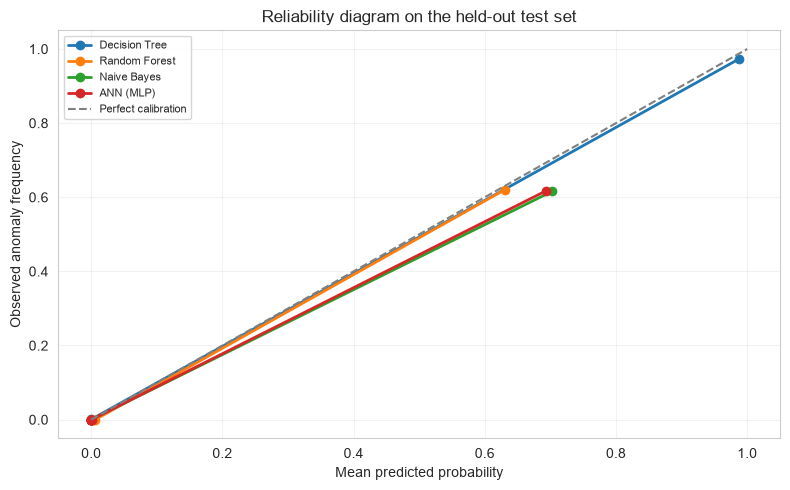

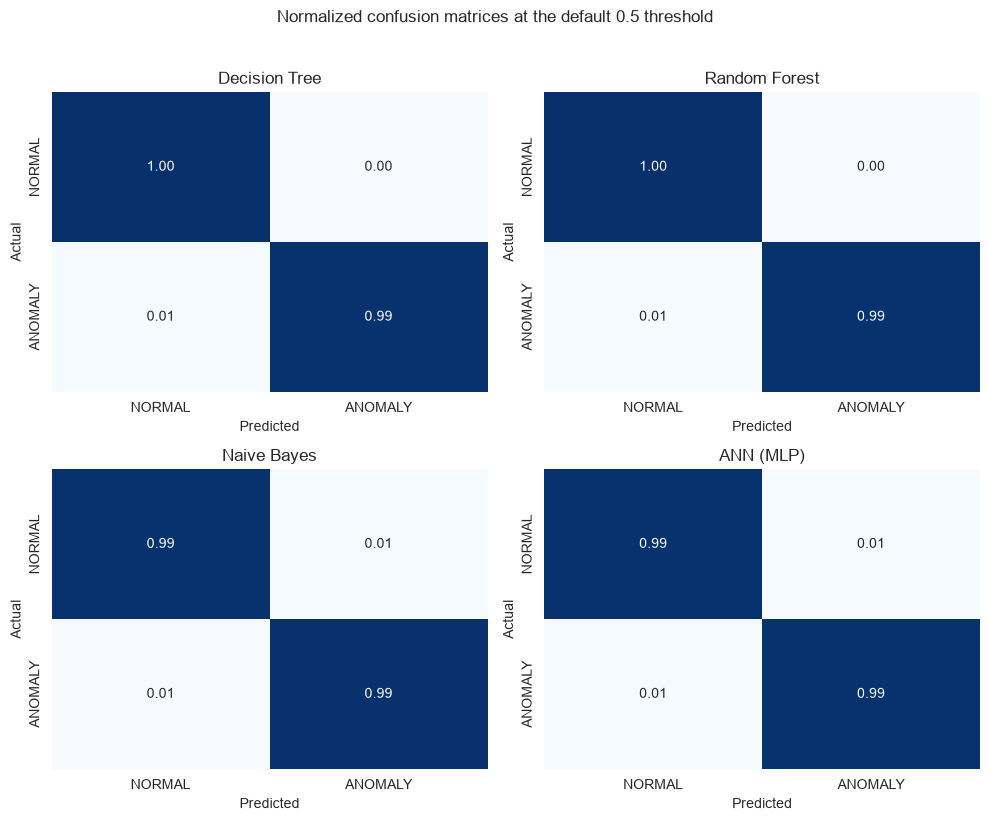

,Brier score,Mean predicted probability,Observed anomaly rate
Model,,,
Decision Tree,0.0019,0.0621,0.0617
Random Forest,0.0020,0.0639,0.0617
Naive Bayes,0.0093,0.0703,0.0617
ANN (MLP),0.0071,0.0694,0.0617


In [36]:
from sklearn.metrics import brier_score_loss

calibration_rows = []
fig, ax = plt.subplots(figsize=(8, 5))
for name, proba in classical_probas.items():
    observed, predicted = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(predicted, observed, marker='o', linewidth=2, label=name)
    calibration_rows.append({
        'Model': name,
        'Brier score': brier_score_loss(y_test, proba),
        'Mean predicted probability': proba.mean(),
        'Observed anomaly rate': y_test.mean(),
    })
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed anomaly frequency')
ax.set_title('Reliability diagram on the held-out test set')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

classical_preds = {
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'Naive Bayes': nb_pred,
    'ANN (MLP)': ann_pred,
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, pred) in zip(axes.ravel(), classical_preds.items()):
    cm = confusion_matrix(y_test, pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=['NORMAL', 'ANOMALY'], yticklabels=['NORMAL', 'ANOMALY'],
                cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Normalized confusion matrices at the default 0.5 threshold', y=1.02)
plt.tight_layout()
plt.show()

display(pd.DataFrame(calibration_rows).set_index('Model').style.format('{:.4f}'))

### Feature sensitivity and model interpretation

Random Forest impurity importance can favor high-variance or highly correlated variables, so permutation importance is a stronger diagnostic: it measures how much held-out PR-AUC falls when one feature is disrupted. The same idea is applied to the ANN, allowing a fair comparison of what the two non-linear models use.

In [ ]:
importance_n = min(10000, len(X_test_scaled))
importance_idx = np.linspace(0, len(X_test_scaled) - 1, importance_n, dtype=int)
X_importance = X_test_scaled[importance_idx]
y_importance = y_test[importance_idx]

rf_permutation = permutation_importance(
    rf_model, X_importance, y_importance,
    scoring='average_precision', n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1
)
rf_perm_series = pd.Series(
    rf_permutation.importances_mean, index=feature_cols
).sort_values(ascending=False)

# ANN does not expose sklearn's predict_proba interface, so calculate the same PR-AUC drop directly.
ann_baseline = average_precision_score(y_importance, ann_model.predict(X_importance, verbose=0).ravel())
ann_perm_values = []
ann_rng = np.random.default_rng(RANDOM_STATE)
for feature_index, feature_name in enumerate(feature_cols):
    permuted = X_importance.copy()
    permuted[:, feature_index] = ann_rng.permutation(permuted[:, feature_index])
    permuted_score = average_precision_score(
        y_importance, ann_model.predict(permuted, verbose=0).ravel()
    )
    ann_perm_values.append(ann_baseline - permuted_score)
ann_perm_series = pd.Series(ann_perm_values, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
rf_perm_series.head(15).sort_values().plot(kind='barh', ax=axes[0], color='forestgreen')
axes[0].set_title('Random Forest permutation importance')
axes[0].set_xlabel('Decrease in PR-AUC')
ann_perm_series.head(15).sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('ANN permutation importance')
axes[1].set_xlabel('Decrease in PR-AUC')
plt.tight_layout()
plt.show()

# NOTE: building a DataFrame from two Series sorted differently makes pandas fall back to
# the alphabetical union of their indexes. A plain .head() would then show whatever sorts
# first (the sensor_00 family), NOT the most important features. Rank explicitly instead.
interpretation_table = pd.DataFrame({
    'Random Forest PR-AUC drop': rf_perm_series,
    'ANN PR-AUC drop': ann_perm_series,
}).fillna(0)
interpretation_table['RF rank'] = interpretation_table['Random Forest PR-AUC drop'].rank(ascending=False).astype(int)
interpretation_table['ANN rank'] = interpretation_table['ANN PR-AUC drop'].rank(ascending=False).astype(int)

_fmt = {'Random Forest PR-AUC drop': '{:.5f}', 'ANN PR-AUC drop': '{:.5f}'}
print('Top 15 by Random Forest permutation importance (ranked, not alphabetical):')
display(interpretation_table.sort_values('Random Forest PR-AUC drop', ascending=False).head(15).style.format(_fmt))
print('\nTop 15 by ANN permutation importance:')
display(interpretation_table.sort_values('ANN PR-AUC drop', ascending=False).head(15).style.format(_fmt))

# The built-in (Gini) chart ranks sensor_00 first, so it is tempting to assume permutation
# importance agrees. Check that explicitly rather than assuming it.
_s00 = [f for f in interpretation_table.index if f.startswith('sensor_00')]
print('\nsensor_00 family under permutation importance:')
display(interpretation_table.loc[_s00].style.format(_fmt))
print(f"RF top feature:  {interpretation_table['Random Forest PR-AUC drop'].idxmax()}")
print(f"ANN top feature: {interpretation_table['ANN PR-AUC drop'].idxmax()}")


### Interpretation for the presentation

The main practical findings are: Random Forest provides the strongest and most stable PR-AUC, Decision Tree is a competitive low-cost baseline, Naïve Bayes preserves recall but creates more false alarms, and the ANN benefits substantially from deliberate threshold selection rather than blindly using 0.5. Rolling standard deviation and rolling mean features appearing among the strongest Random Forest signals supports the engineering interpretation that short-term instability is informative for anomaly detection.

In [38]:
ann_val_proba = ann_model.predict(X_val, verbose=0).ravel()
ann_val_f1 = [f1_score(y_val, (ann_val_proba >= t).astype(int), zero_division=0) for t in threshold_grid]
ann_selected_threshold = threshold_grid[int(np.argmax(ann_val_f1))]
ann_test_at_selected = (ann_proba >= ann_selected_threshold).astype(int)

ann_threshold_summary = pd.DataFrame([{
    'Selected threshold': ann_selected_threshold,
    'Validation F1': max(ann_val_f1),
    'Test precision': precision_score(y_test, ann_test_at_selected, zero_division=0),
    'Test recall': recall_score(y_test, ann_test_at_selected, zero_division=0),
    'Test F1': f1_score(y_test, ann_test_at_selected, zero_division=0),
}], index=['ANN (MLP)'])
display(ann_threshold_summary.style.format('{:.3f}'))

,Selected threshold,Validation F1,Test precision,Test recall,Test F1
ANN (MLP),0.875,0.975,0.925,0.988,0.955


## 12. Preparing sequences for LSTM

Unlike the tabular models above, an LSTM consumes a **window of consecutive past readings**
to make one prediction, which lets it learn temporal patterns (e.g. a sensor drifting over
several minutes before a failure) rather than judging each timestamp in isolation.

* Sequence length **T = 20** minutes.
* Input at time *t*: the raw sensor readings (scaled, no rolling features — the LSTM builds
  its own temporal representation) from *t-T+1* to *t*, shape **(T, 51)**.
* Label at time *t*: `anomaly` at time *t* (i.e. "is the pump in an anomalous state right
  now, given the last 20 minutes of readings").
* Sequences are generated from the full chronological array so that every window only ever
  looks **backwards** in time; a sequence is then assigned to train/validation/test
  according to which split its *label* timestamp falls in — this respects the same
  1 July 2018 time-based split used for the tabular models, so results are directly
  comparable.
* Because a full ~220k x 20 x 51 tensor is unnecessarily large for a class-imbalanced
  demonstration model, we keep **all** anomalous-labelled windows from the training portion
  but randomly **undersample the majority (NORMAL) windows** used for training (a common
  technique for extreme imbalance, alongside the class-weighting used above) — the
  validation and test sets keep every window, so evaluation still reflects the true
  (imbalanced) real-world distribution.

In [39]:
T = 20
lstm_feature_cols = sensor_cols  # raw sensors only, scaled below
full_scaled = StandardScaler().fit(train_df[lstm_feature_cols]).transform(df_clean[lstm_feature_cols])
full_labels = df_clean['anomaly'].values
n = len(df_clean)

# valid window end-indices (need at least T rows of history)
valid_idx = np.arange(T - 1, n)

# assign each candidate index to train / val / test using the SAME time cutoffs as before
val_cutoff_idx = int(len(train_df) * 0.9)   # last 10% of the training timeline -> validation
train_idx = valid_idx[valid_idx < val_cutoff_idx]
val_idx = valid_idx[(valid_idx >= val_cutoff_idx) & (valid_idx < split_idx)]
test_idx = valid_idx[valid_idx >= split_idx]

print(f'Candidate windows -> train: {len(train_idx):,}, val: {len(val_idx):,}, test: {len(test_idx):,}')


Candidate windows -> train: 117,917, val: 13,104, test: 89,280


In [40]:
# Undersample majority-class windows in the TRAINING portion only
rng = np.random.default_rng(RANDOM_STATE)
train_labels_at_idx = full_labels[train_idx]
anomaly_train_idx = train_idx[train_labels_at_idx == 1]
normal_train_idx = train_idx[train_labels_at_idx == 0]

MAX_NORMAL_TRAIN_WINDOWS = 30000
if len(normal_train_idx) > MAX_NORMAL_TRAIN_WINDOWS:
    normal_train_idx = rng.choice(normal_train_idx, size=MAX_NORMAL_TRAIN_WINDOWS, replace=False)

train_idx_sampled = np.sort(np.concatenate([anomaly_train_idx, normal_train_idx]))
rng.shuffle(train_idx_sampled)

print(f'Training windows after undersampling NORMAL: {len(train_idx_sampled):,} '
      f'(anomaly: {len(anomaly_train_idx):,}, normal kept: {len(normal_train_idx):,})')


Training windows after undersampling NORMAL: 35,975 (anomaly: 5,975, normal kept: 30,000)


In [41]:
def build_sequences(end_indices, features, labels, T):
    X = np.empty((len(end_indices), T, features.shape[1]), dtype=np.float32)
    y = np.empty(len(end_indices), dtype=np.float32)
    for i, end in enumerate(end_indices):
        X[i] = features[end - T + 1: end + 1]
        y[i] = labels[end]
    return X, y

X_lstm_train, y_lstm_train = build_sequences(train_idx_sampled, full_scaled, full_labels, T)
X_lstm_val, y_lstm_val = build_sequences(val_idx, full_scaled, full_labels, T)
X_lstm_test, y_lstm_test = build_sequences(test_idx, full_scaled, full_labels, T)

print('X_lstm_train:', X_lstm_train.shape, ' positive rate:', y_lstm_train.mean().round(4))
print('X_lstm_val:  ', X_lstm_val.shape, ' positive rate:', y_lstm_val.mean().round(4))
print('X_lstm_test: ', X_lstm_test.shape, ' positive rate:', y_lstm_test.mean().round(4))


X_lstm_train: (35975, 20, 50)  positive rate: 0.1661
X_lstm_val:   (13104, 20, 50)  positive rate: 0.2289
X_lstm_test:  (89280, 20, 50)  positive rate: 0.0617


## 13. Model 5 — LSTM

Two stacked LSTM layers extract a temporal representation of each 20-minute window, followed
by a small dense head. Class weights (recomputed for the LSTM's own training set, after
undersampling) again counter the residual imbalance, and early stopping on validation
ROC-AUC prevents overfitting.

In [ ]:
lstm_class_weights_arr = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_lstm_train)
lstm_class_weight_dict = {0: lstm_class_weights_arr[0], 1: lstm_class_weights_arr[1]}
print('LSTM class weights:', lstm_class_weight_dict)

# Reproducibility: re-seed immediately before the model is built. The global seed in
# Section 1 only takes effect when that cell runs, so re-executing this cell alone would
# otherwise give different weight initialisation and a different early-stopping epoch.
keras.utils.set_random_seed(RANDOM_STATE)

lstm_model = keras.Sequential([
    layers.Input(shape=(T, len(lstm_feature_cols))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), 'accuracy'],
)

lstm_early_stop = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=4, restore_best_weights=True)

t0 = time.time()
lstm_history = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=20, batch_size=256,
    class_weight=lstm_class_weight_dict,
    callbacks=[lstm_early_stop],
    verbose=1,
)
train_times['LSTM'] = time.time() - t0


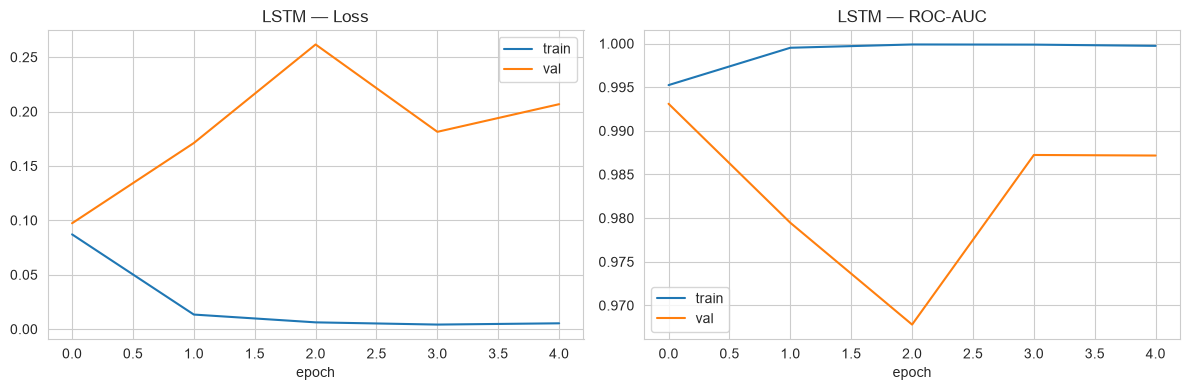

===== LSTM =====
              precision    recall  f1-score   support

      NORMAL       1.00      0.99      1.00     83771
     ANOMALY       0.89      0.99      0.94      5509

    accuracy                           0.99     89280
   macro avg       0.95      0.99      0.97     89280
weighted avg       0.99      0.99      0.99     89280

ROC-AUC: 0.9996   PR-AUC: 0.9959
Confusion matrix (rows=actual, cols=predicted):
[[83124   647]
 [   37  5472]]


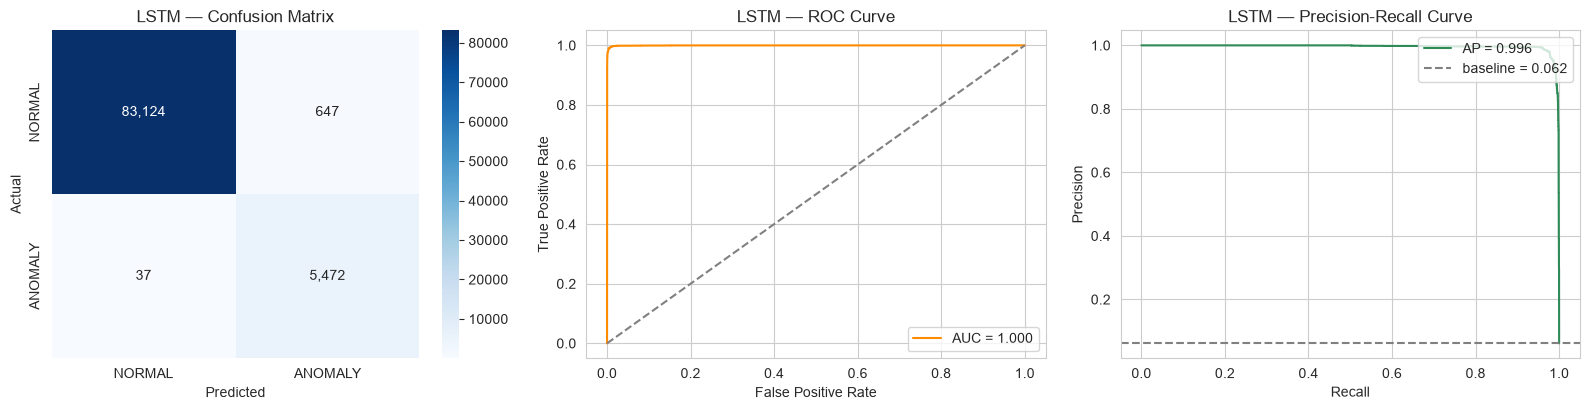

{'Accuracy': 0.9923387096774193,
 'Precision': 0.8942637685896389,
 'Recall': 0.993283717553095,
 'F1': 0.9411764705882353,
 'ROC-AUC': 0.9996497314239576,
 'PR-AUC': 0.9959065075304665}

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lstm_history.history['loss'], label='train')
axes[0].plot(lstm_history.history['val_loss'], label='val')
axes[0].set_title('LSTM — Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(lstm_history.history['auc'], label='train')
axes[1].plot(lstm_history.history['val_auc'], label='val')
axes[1].set_title('LSTM — ROC-AUC'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

lstm_proba = lstm_model.predict(X_lstm_test, verbose=0).ravel()
lstm_pred = (lstm_proba >= 0.5).astype(int)
evaluate_model('LSTM', y_lstm_test, lstm_pred, lstm_proba)


### LSTM — visualising predictions over time

Aggregate metrics can hide *when* a model succeeds or fails. Plotting the LSTM's predicted
anomaly probability across the entire test period, against the true machine status, shows
whether it tracks the shape of real anomaly episodes or just reacts to noise.

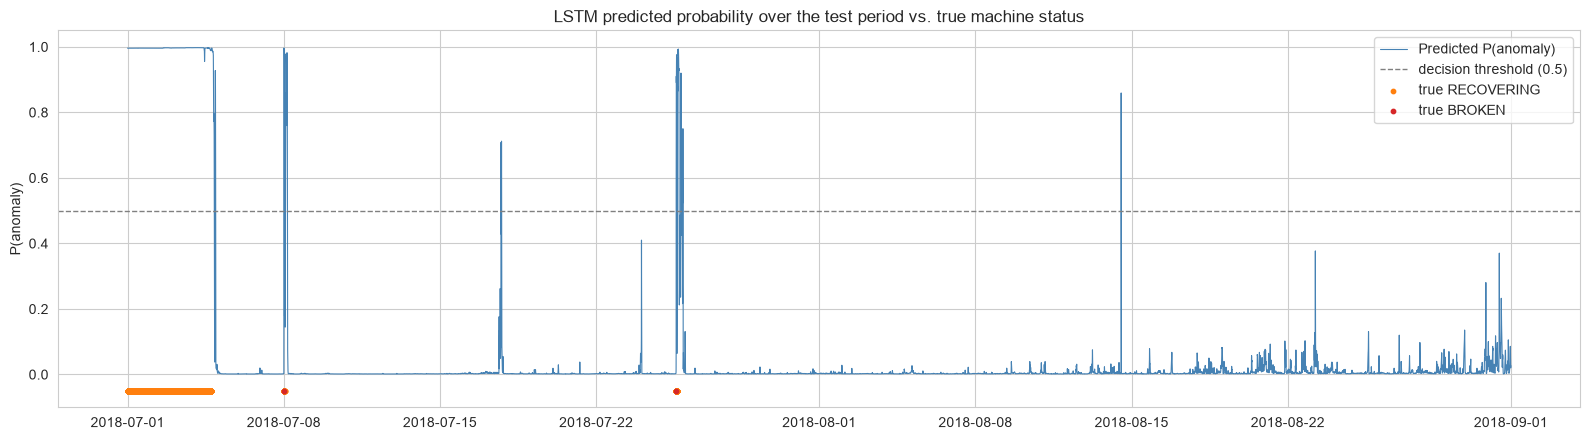

In [44]:
test_timestamps_lstm = df_clean['timestamp'].values[test_idx]
test_status_lstm = df_clean['machine_status'].values[test_idx]

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(test_timestamps_lstm, lstm_proba, color='steelblue', linewidth=0.8, label='Predicted P(anomaly)')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='decision threshold (0.5)')
for status, color in status_colors.items():
    if status == 'NORMAL':
        continue
    mask = test_status_lstm == status
    if mask.any():
        ax.scatter(test_timestamps_lstm[mask], np.full(mask.sum(), -0.05), color=color, s=10,
                   label=f'true {status}', zorder=3, clip_on=False)
ax.set_ylim(-0.1, 1.05)
ax.set_ylabel('P(anomaly)')
ax.set_title('LSTM predicted probability over the test period vs. true machine status')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


### LSTM — threshold tuning

The default decision threshold of 0.5 is arbitrary. Since maintenance decision-making usually
cares more about **recall** than **precision** (missing a real failure is far costlier than
an extra false alarm — see the discussion in the conclusion), it's worth checking whether a
different threshold gives a better trade-off, and reporting the threshold that maximises F1
as a concrete, defensible alternative to the default.

In [ ]:
# Threshold grid extended into the saturated region: the LSTM's sigmoid output piles up
# near 1, so a grid stopping at 0.95 can return the grid edge rather than a true optimum.
lstm_threshold_grid = np.unique(np.concatenate([
    np.linspace(0.05, 0.95, 37),
    np.linspace(0.95, 0.999, 50),
]))

# Select the operating point on the VALIDATION window, never on test. This mirrors the
# procedure used for the tabular models in Section 10. Choosing it on the test set would
# be tuning a decision on the same data used to report the final number.
lstm_val_proba = lstm_model.predict(X_lstm_val, verbose=0).ravel()
lstm_val_f1 = [f1_score(y_lstm_val, (lstm_val_proba >= t).astype(int), zero_division=0)
               for t in lstm_threshold_grid]
lstm_selected_threshold = float(lstm_threshold_grid[int(np.argmax(lstm_val_f1))])
print(f"Selected on validation: threshold = {lstm_selected_threshold:.3f}  "
      f"(validation F1 = {max(lstm_val_f1):.4f})")

lstm_pred_tuned = (lstm_proba >= lstm_selected_threshold).astype(int)

lstm_threshold_summary = pd.DataFrame([{
    'Selected threshold': lstm_selected_threshold,
    'Validation F1': max(lstm_val_f1),
    'Test precision': precision_score(y_lstm_test, lstm_pred_tuned, zero_division=0),
    'Test recall': recall_score(y_lstm_test, lstm_pred_tuned, zero_division=0),
    'Test F1': f1_score(y_lstm_test, lstm_pred_tuned, zero_division=0),
}], index=['LSTM'])
display(lstm_threshold_summary.style.format('{:.3f}'))

print(f"Test F1 at the selected threshold: "
      f"{f1_score(y_lstm_test, lstm_pred_tuned, zero_division=0):.4f}   "
      f"(vs {f1_score(y_lstm_test, lstm_pred, zero_division=0):.4f} at the default 0.5)")

# NOTE: results['LSTM'] is deliberately left at the default 0.5 threshold so that the
# Section 14 comparison stays apples-to-apples with the four tabular models. Every model's
# tuned operating point is reported together in its own table further down.

val_prec = [precision_score(y_lstm_val, (lstm_val_proba >= t).astype(int), zero_division=0)
            for t in lstm_threshold_grid]
val_rec = [recall_score(y_lstm_val, (lstm_val_proba >= t).astype(int), zero_division=0)
           for t in lstm_threshold_grid]
test_f1_curve = [f1_score(y_lstm_test, (lstm_proba >= t).astype(int), zero_division=0)
                 for t in lstm_threshold_grid]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(lstm_threshold_grid, val_prec, label='Precision (validation)', linewidth=1.5)
ax.plot(lstm_threshold_grid, val_rec, label='Recall (validation)', linewidth=1.5)
ax.plot(lstm_threshold_grid, lstm_val_f1, label='F1 (validation)', linewidth=2.5)
ax.plot(lstm_threshold_grid, test_f1_curve, label='F1 (test, reported only)',
        linewidth=1.2, linestyle='--', color='gray')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='default (0.5)')
ax.axvline(lstm_selected_threshold, color='red', linestyle=':',
           label=f'selected on validation ({lstm_selected_threshold:.3f})')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
ax.set_title('LSTM - threshold selected on validation, reported on test')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()

print(f"\nConfusion matrix at the selected threshold {lstm_selected_threshold:.3f}:")
print(confusion_matrix(y_lstm_test, lstm_pred_tuned))


### LSTM — did it catch every real anomaly episode?

Per-timestamp metrics can look good even when a model only catches part of an episode. A
more operationally meaningful question: **for each real anomaly episode in the test period,
did the model raise at least one alert during it, and how many minutes into the episode did
that first alert come?** A short lag means the model would have flagged the problem quickly
enough to be genuinely useful; a long lag or a miss entirely is a real-world failure even if
the aggregate metrics look fine. (One episode straddles the train/test split boundary —
its start predates the test window, so a lag reported for it is measured from that true
start and partly reflects the split point rather than model performance.)

In [46]:
test_episodes = episodes[episodes['end'] >= split_date].reset_index(drop=True)

def episode_detection(pred, pred_timestamps, episodes_df):
    """For each episode, check whether `pred` raised >=1 alert inside it, and the lag
    (in minutes) from the episode's start to the first correct alert."""
    pred = np.asarray(pred)
    pred_timestamps = pd.Series(pd.to_datetime(pred_timestamps)).reset_index(drop=True)
    rows = []
    for _, ep in episodes_df.iterrows():
        in_window = (pred_timestamps >= ep['start']) & (pred_timestamps <= ep['end'])
        idx_in_window = np.where(in_window.values)[0]
        flagged = pred[idx_in_window] if len(idx_in_window) else np.array([])
        detected = bool((flagged == 1).any()) if len(flagged) else False
        if detected:
            first_hit_pos = int(np.argmax(flagged == 1))
            lag_min = (pred_timestamps.iloc[idx_in_window[first_hit_pos]] - ep['start']).total_seconds() / 60
        else:
            lag_min = np.nan
        rows.append({'start': ep['start'], 'duration_min': ep['duration_min'],
                     'contains_broken': ep['contains_broken'], 'detected': detected, 'lag_min': lag_min})
    return pd.DataFrame(rows)

lstm_detection = episode_detection(lstm_pred, test_timestamps_lstm, test_episodes)
print(lstm_detection)
print(f"\nEpisodes detected: {lstm_detection['detected'].sum()} / {len(lstm_detection)}")


                start  duration_min  contains_broken  detected  lag_min
0 2018-06-28 22:00:00          8391             True      True   3000.0
1 2018-07-08 00:11:00            42             True      True      0.0
2 2018-07-25 14:00:00            76             True      True     10.0

Episodes detected: 3 / 3


## 14. Model comparison

All five models were evaluated on their respective (time-based) test sets using the same
anomaly definition, so metrics are directly comparable — note the LSTM's test set is very
slightly smaller (it loses the first `T-1` rows of the overall series to build its first
window) and starts at a slightly later timestamp, but both test sets share the same tail of
the timeline and the same ~6-7% positive rate.

In [47]:
results_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']]
results_df = results_df.sort_values('F1', ascending=False)
display(results_df.style.format('{:.4f}').background_gradient(cmap='Greens', axis=0))


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Decision Tree,0.9981,0.9795,0.9902,0.9848,0.9952,0.9821
Random Forest,0.9977,0.9739,0.9897,0.9817,0.9998,0.9969
LSTM,0.9961,0.9525,0.9860,0.9690,0.9996,0.9959
ANN (MLP),0.9909,0.8768,0.9913,0.9306,0.9997,0.9957
Naive Bayes,0.9906,0.8725,0.9935,0.9290,0.9945,0.8776


### Model comparison at deliberately selected thresholds

The table above reports every model at the **default 0.5 threshold**, which is the correct
like-for-like comparison of the models as trained. The table below reports every model at a
threshold **selected on validation data** (Sections 10, 11 and 13). That is the comparison to
use when the question is "what would we deploy", because nothing about a 0.5 cutoff is
special - it is simply the default.

Both are legitimate; what matters is not mixing them. Any figure quoting precision, recall or
F1 must state which threshold it uses. ROC-AUC and PR-AUC are identical in both tables because
they are threshold-independent by construction.


In [ ]:
tuned_rows = pd.concat([
    validation_threshold_results,   # Decision Tree, Random Forest, Naive Bayes (Section 10)
    ann_threshold_summary,          # ANN (MLP) (Section 11)
    lstm_threshold_summary,         # LSTM (Section 13)
])

tuned_probas = {
    'Decision Tree': (dt_proba, y_test),
    'Random Forest': (rf_proba, y_test),
    'Naive Bayes': (nb_proba, y_test),
    'ANN (MLP)': (ann_proba, y_test),
    'LSTM': (lstm_proba, y_lstm_test),
}
tuned_accuracy = {n: accuracy_score(y, (p >= tuned_rows.loc[n, 'Selected threshold']).astype(int))
                  for n, (p, y) in tuned_probas.items()}

results_tuned_df = pd.DataFrame({
    'Threshold': tuned_rows['Selected threshold'],
    'Accuracy': pd.Series(tuned_accuracy),
    'Precision': tuned_rows['Test precision'],
    'Recall': tuned_rows['Test recall'],
    'F1': tuned_rows['Test F1'],
    'ROC-AUC': pd.Series({k: results[k]['ROC-AUC'] for k in tuned_probas}),
    'PR-AUC': pd.Series({k: results[k]['PR-AUC'] for k in tuned_probas}),
}).sort_values('F1', ascending=False)

print('Models at validation-selected thresholds (ROC-AUC / PR-AUC are threshold-independent):')
display(results_tuned_df.style.format('{:.4f}').background_gradient(cmap='Greens', axis=0))

f1_shift = pd.DataFrame({
    'F1 @ 0.5': pd.Series({k: results[k]['F1'] for k in tuned_probas}),
    'Threshold': results_tuned_df['Threshold'],
    'F1 @ selected': results_tuned_df['F1'],
})
f1_shift['Change'] = f1_shift['F1 @ selected'] - f1_shift['F1 @ 0.5']
print('\nWhat deliberate threshold selection is worth, per model:')
display(f1_shift.sort_values('Change', ascending=False).style.format('{:.4f}'))


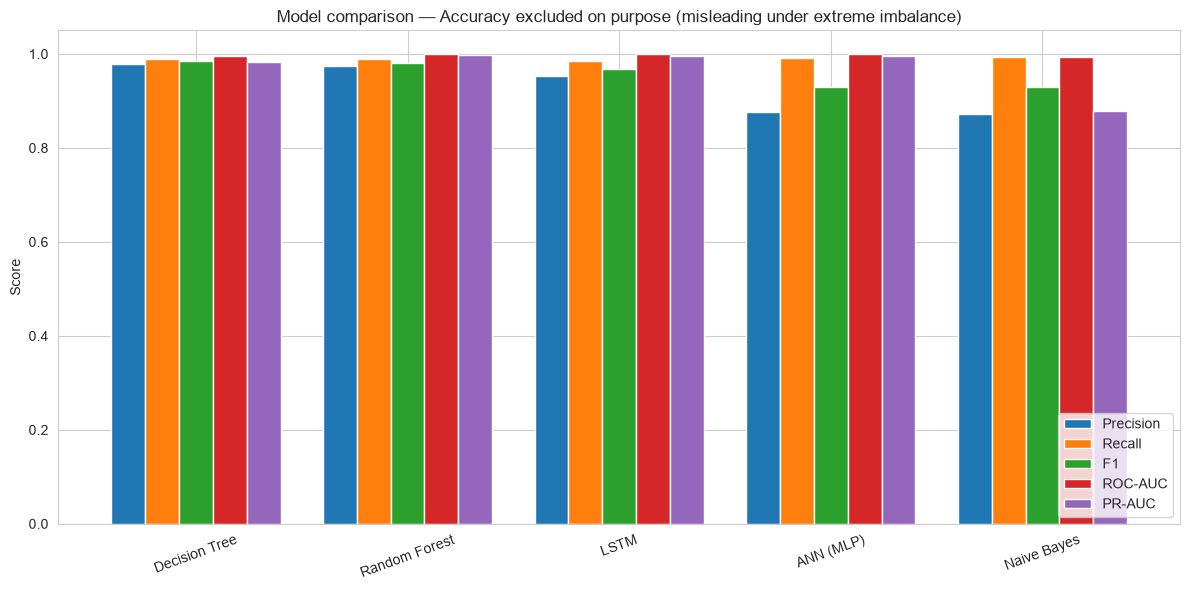


Accuracy for reference (note how close every model — including a naive all-NORMAL predictor at ~93-94% — scores, versus the much larger spread in Recall/F1/PR-AUC):
Decision Tree    0.998118
Random Forest    0.997726
LSTM             0.996102
ANN (MLP)        0.990871
Naive Bayes      0.990636
Name: Accuracy, dtype: float64


In [48]:
metrics_to_plot = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
plot_df = results_df[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model comparison — Accuracy excluded on purpose (misleading under extreme imbalance)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print('\nAccuracy for reference (note how close every model — including a naive all-NORMAL '
      'predictor at ~93-94% — scores, versus the much larger spread in Recall/F1/PR-AUC):')
print(results_df['Accuracy'])


### Combined ROC and Precision-Recall curves

Overlaying every model's ROC and PR curves on the same axes makes the relative ranking (and
how close Random Forest and LSTM really are at the top) much easier to read than the bar
chart alone — especially in the top-left / top-right corners, which is where the real
differences between "good" models on this dataset actually live.

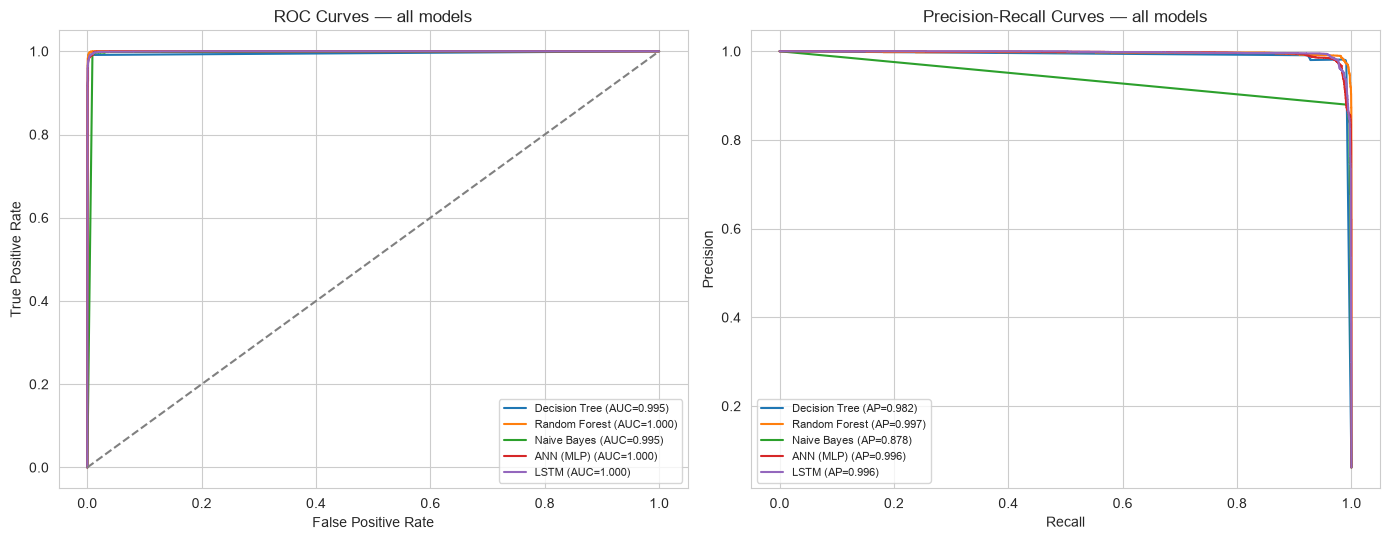

In [49]:
model_probas = {
    'Decision Tree': (dt_proba, y_test),
    'Random Forest': (rf_proba, y_test),
    'Naive Bayes': (nb_proba, y_test),
    'ANN (MLP)': (ann_proba, y_test),
    'LSTM': (lstm_proba, y_lstm_test),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for name, (proba, y_true) in model_probas.items():
    fpr, tpr, _ = roc_curve(y_true, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_true, proba):.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curves — all models')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=8)

for name, (proba, y_true) in model_probas.items():
    prec_c, rec_c, _ = precision_recall_curve(y_true, proba)
    axes[1].plot(rec_c, prec_c, label=f'{name} (AP={average_precision_score(y_true, proba):.3f})')
axes[1].set_title('Precision-Recall Curves — all models')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()


### Training time — a practical deployment consideration

Predictive performance isn't the only thing that matters operationally: retraining cadence
and compute budget matter too, especially if the model would be periodically retrained as
more data comes in. Here's how long each model took to train in this run (same machine,
single run each — indicative, not a rigorous benchmark).

,Training time (s)
Naive Bayes,0.12
ANN (MLP),1.66
Decision Tree,3.55
Random Forest,7.39
LSTM,15.70


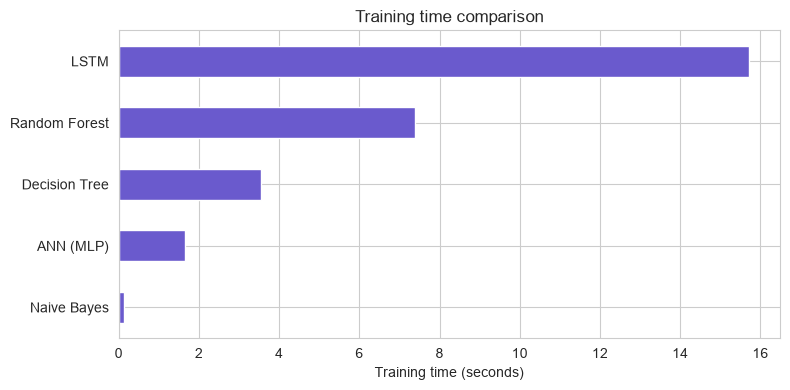

In [50]:
time_df = pd.Series(train_times, name='Training time (s)').sort_values()
display(time_df.to_frame().style.format('{:.2f}'))

fig, ax = plt.subplots(figsize=(8, 4))
time_df.plot(kind='barh', ax=ax, color='slateblue')
ax.set_xlabel('Training time (seconds)')
ax.set_title('Training time comparison')
plt.tight_layout()
plt.show()


### Which models actually caught each real anomaly episode?

Extending the per-episode detection check from the LSTM section to every model: for each
real anomaly episode in the test period, did each model raise at least one alert during it?
This is arguably the most operationally relevant comparison in this notebook — a model that
scores well on aggregate per-minute metrics but misses an entire episode is far more
concerning in practice than one that scores slightly lower but never misses an episode.

In [51]:
per_model_detection = pd.DataFrame({
    'start': test_episodes['start'].values,
    'duration_min': test_episodes['duration_min'].values,
    'contains_broken': test_episodes['contains_broken'].values,
})

model_preds_for_episodes = {
    'Decision Tree': (dt_pred, test_df['timestamp'].values),
    'Random Forest': (rf_pred, test_df['timestamp'].values),
    'Naive Bayes': (nb_pred, test_df['timestamp'].values),
    'ANN (MLP)': (ann_pred, test_df['timestamp'].values),
    'LSTM': (lstm_pred, test_timestamps_lstm),
}

for name, (pred, ts) in model_preds_for_episodes.items():
    det = episode_detection(pred, ts, test_episodes)
    per_model_detection[name] = det['detected'].values

display(per_model_detection)
print()
print(f"Episodes detected out of {len(per_model_detection)}:")
print(per_model_detection[list(model_preds_for_episodes.keys())].sum())


,start,duration_min,contains_broken,Decision Tree,Random Forest,Naive Bayes,ANN (MLP),LSTM
0,2018-06-28 22:00:00,8391,True,True,True,True,True,True
1,2018-07-08 00:11:00,42,True,True,True,True,True,True
2,2018-07-25 14:00:00,76,True,True,True,True,True,True



Episodes detected out of 3:
Decision Tree    3
Random Forest    3
Naive Bayes      3
ANN (MLP)        3
LSTM             3
dtype: int64


## 15. Hyperparameter tuning with GridSearchCV

Every model so far used hyperparameters we fixed by hand. That is a defensible starting point,
but it leaves an obvious question open: were those values any good? `GridSearchCV` answers it by
searching a parameter grid with cross-validation built in, so each candidate is scored on folds
it did not train on.

Two deliberate choices. First, we search on the **training split only** - the test period is
never touched, so this cannot leak. Second, we score on `average_precision` (PR-AUC) rather than
accuracy, for the reason that runs through this whole notebook: under a 6.6% positive rate,
accuracy cannot separate a useful model from a useless one.

The search is run on a stratified subsample of the training rows to keep notebook execution time
reasonable. The point is to test whether our hand-picked settings were near-optimal, not to
squeeze out the last fraction of a percent.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Subsample the TRAINING split only - the test period is never involved in the search.
gs_n = min(40000, len(X_train_scaled))
gs_rng = np.random.default_rng(RANDOM_STATE)
gs_idx = gs_rng.choice(len(X_train_scaled), size=gs_n, replace=False)
X_gs, y_gs = X_train_scaled[gs_idx], y_train[gs_idx]
print(f'GridSearchCV on {gs_n:,} training rows ({y_gs.mean()*100:.2f}% anomalous)')

gs_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grids = {
    'Decision Tree': (
        DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        {'max_depth': [6, 10, 15], 'min_samples_leaf': [5, 20, 50]},
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
        {'n_estimators': [100, 200], 'max_depth': [10, 15, None], 'min_samples_leaf': [1, 5]},
    ),
}

from sklearn.base import clone

gs_results, gs_best = {}, {}
for name, (estimator, grid) in grids.items():
    search = GridSearchCV(estimator, grid, scoring='average_precision',
                          cv=gs_cv, n_jobs=-1, refit=False)
    t0 = time.time()
    search.fit(X_gs, y_gs)
    # The search ran on a subsample for speed. Refit the winning configuration on the FULL
    # training split, so the test comparison below is like for like with the hand-picked
    # models (which were also trained on the full training split).
    gs_best[name] = clone(estimator).set_params(**search.best_params_).fit(X_train_scaled, y_train)
    gs_results[name] = {
        'Best params': search.best_params_,
        'Best CV PR-AUC': search.best_score_,
        'Search time (s)': time.time() - t0,
        'Combinations': len(search.cv_results_['params']),
    }
    print(f"{name}: best CV PR-AUC {search.best_score_:.4f} with {search.best_params_}")

display(pd.DataFrame(gs_results).T)

# Does the tuned configuration beat what we chose by hand, on the held-out test period?
hand_picked = {'Decision Tree': dt_proba, 'Random Forest': rf_proba}
compare_rows = []
for name, model in gs_best.items():
    tuned_proba = model.predict_proba(X_test_scaled)[:, 1]
    for label, proba in (('hand-picked', hand_picked[name]), ('GridSearchCV', tuned_proba)):
        pred = (proba >= 0.5).astype(int)
        compare_rows.append({
            'Model': name, 'Configuration': label,
            'PR-AUC': average_precision_score(y_test, proba),
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Precision @0.5': precision_score(y_test, pred, zero_division=0),
            'Recall @0.5': recall_score(y_test, pred, zero_division=0),
            'F1 @0.5': f1_score(y_test, pred, zero_division=0),
        })
gs_compare = pd.DataFrame(compare_rows).set_index(['Model', 'Configuration'])
print('\nTuned vs hand-picked, both trained on the full training split, scored on the test period:')
display(gs_compare.style.format('{:.4f}'))

print('\nNote the gap between the cross-validated PR-AUC above and the test PR-AUC here.')
print('The folds are shuffled within the training period, so neighbouring minutes of the same')
print('episode land in both the fitting and the scoring fold. That makes the CV score optimistic')
print('for time-series data. The chronological test period is the honest number.')


## 16. Unsupervised cross-check: does the anomaly state separate without labels?

Every result so far is supervised: the models were told which minutes were anomalous. That
invites a fair challenge - are the models learning real structure, or is a 0.99 PR-AUC an
artefact of how we framed the problem?

K-means lets us test this without using the labels at all. We cluster the scaled sensor
readings, then compare the partition against the true labels *after the fact*. If a purely
geometric split of the sensor space lines up with NORMAL versus ANOMALY, the separation is a
property of the data rather than of our supervision.

We sweep k from 2 to 6 and report silhouette and Davies-Bouldin scores, as covered in Week 11:
silhouette is higher when clusters are tight and well separated, Davies-Bouldin lower.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Raw sensors only, scaled. Labels are held back and used only to score the result afterwards.
km_n = 30000
km_rng = np.random.default_rng(RANDOM_STATE)
km_idx = np.sort(km_rng.choice(len(df_clean), size=km_n, replace=False))
km_X = StandardScaler().fit_transform(df_clean.iloc[km_idx][sensor_cols])
km_y = df_clean.iloc[km_idx]['anomaly'].values
print(f'K-means on {km_n:,} rows x {len(sensor_cols)} raw sensors '
      f'({km_y.mean()*100:.2f}% anomalous)')

# --- Elbow, and how well each k recovers the anomaly class -----------------------------
inertias, sweep = [], []
labels_by_k = {}
for k in range(1, 9):
    km_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(km_X)
    inertias.append(km_k.inertia_)
    if k == 1:
        continue
    labels_by_k[k] = km_k.labels_
    if k > 6:
        continue
    # Which combination of clusters best matches the anomaly class? (scored after the fact)
    best_f1, best_sel = 0.0, None
    for bits in range(1, 2 ** k - 1):
        sel = [j for j in range(k) if bits >> j & 1]
        f = f1_score(km_y, np.isin(km_k.labels_, sel).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_sel = f, sel
    rates = [km_y[km_k.labels_ == j].mean() for j in range(k)]
    sweep.append({
        'k': k,
        'Silhouette': silhouette_score(km_X, km_k.labels_),
        'Davies-Bouldin': davies_bouldin_score(km_X, km_k.labels_),
        'Best F1 vs labels': best_f1,
        'Clusters used': str(best_sel),
        'Purest cluster anomaly rate': max(rates),
    })

sweep_df = pd.DataFrame(sweep).set_index('k')
print(f'\nBaseline anomaly rate in this sample: {km_y.mean():.4f}')
display(sweep_df.style.format({'Silhouette': '{:.4f}', 'Davies-Bouldin': '{:.4f}',
                               'Best F1 vs labels': '{:.4f}',
                               'Purest cluster anomaly rate': '{:.4f}'}))

best_k = int(sweep_df['Silhouette'].idxmax())
print(f'Silhouette peaks at k = {best_k}.')

# --- The winning partition in detail ---------------------------------------------------
lab = labels_by_k[best_k]
ct = pd.crosstab(pd.Series(lab, name='K-means cluster'),
                 pd.Series(km_y, name='True label').map({0: 'NORMAL', 1: 'ANOMALY'}))
print(f'\nk={best_k} clusters against the labels they never saw:')
display(ct)

anom_rate = (ct['ANOMALY'] / ct.sum(axis=1)) if 'ANOMALY' in ct else None
ac = int(anom_rate.idxmax())
km_pred = (lab == ac).astype(int)
print(f'Cluster {ac} is {anom_rate.max()*100:.1f}% anomalous against a {km_y.mean()*100:.2f}% baseline.')
print(f'  Treating it as the anomaly cluster:  precision {precision_score(km_y, km_pred, zero_division=0):.4f}'
      f'   recall {recall_score(km_y, km_pred, zero_division=0):.4f}'
      f'   F1 {f1_score(km_y, km_pred, zero_division=0):.4f}')
print(f'  For reference, the supervised Random Forest reaches F1 '
      f"{results['Random Forest']['F1']:.4f} on the real test set.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(range(1, 9), inertias, marker='o', color='#454BA0')
axes[0].axvline(best_k, color='#AD3326', ls=':', lw=1.4, label=f'k={best_k}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('within-cluster sum of squares')
axes[0].set_title('Elbow curve'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(sweep_df.index, sweep_df['Silhouette'], marker='o', color='#454BA0', label='Silhouette')
axes[1].plot(sweep_df.index, sweep_df['Best F1 vs labels'], marker='s', color='#C98115',
             label='Best F1 vs true labels')
axes[1].set_xlabel('k'); axes[1].set_ylabel('score'); axes[1].set_ylim(0, 1)
axes[1].set_title('Cluster quality and label agreement'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

bottom = np.zeros(len(ct))
for col, colour in (('NORMAL', '#454BA0'), ('ANOMALY', '#AD3326')):
    if col in ct:
        axes[2].bar(ct.index.astype(str), ct[col], bottom=bottom, label=col, color=colour)
        bottom += ct[col].values
axes[2].set_xlabel(f'K-means cluster (k={best_k})'); axes[2].set_ylabel('rows')
axes[2].set_title('Cluster composition'); axes[2].legend(fontsize=8); axes[2].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# The conclusion quotes numbers from THIS run. Generating them here means the write-up
# cannot drift away from the notebook's actual outputs.
def _md_table(frame, cols, fmt='{:.4f}'):
    print('| Model | ' + ' | '.join(cols) + ' |')
    print('|---|' + '---|' * len(cols))
    for name, row in frame.iterrows():
        print(f'| {name} | ' + ' | '.join(fmt.format(row[col]) for col in cols) + ' |')

print('Model comparison at the default 0.5 threshold')
_md_table(results_df, ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'])

print('\nModel comparison at validation-selected thresholds')
_md_table(results_tuned_df, ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'])

print('\nTraining time (seconds)')
for name, secs in time_df.items():
    print(f'  {name}: {secs:.2f}s')

acc_rng = results_df['Accuracy'].max() - results_df['Accuracy'].min()
pr_rng = results_df['PR-AUC'].max() - results_df['PR-AUC'].min()
print(f"\nAccuracy spans {results_df['Accuracy'].min():.4f} - {results_df['Accuracy'].max():.4f} (range {acc_rng:.4f})")
print(f"PR-AUC   spans {results_df['PR-AUC'].min():.4f} - {results_df['PR-AUC'].max():.4f} (range {pr_rng:.4f})")
print(f'PR-AUC spread is {pr_rng / acc_rng:.1f}x wider than the accuracy spread.')


## 17. Conclusion & discussion

**Why accuracy is misleading here.** The anomaly class is only ~6-7% of the data, so a
trivial classifier that *always* predicts `NORMAL` already achieves ~93-94% accuracy while
catching **zero** real anomalies (0% recall). Every model above scores in a fairly narrow,
high accuracy band regardless of how well it actually detects anomalies — the real
differentiation between models only shows up in **Recall, Precision, F1, ROC-AUC and
PR-AUC**, which is why the assessment brief (and standard practice for imbalanced problems)
calls those out specifically.

**Precision vs. Recall trade-off for fault detection.** In this domain, missing a
real anomaly (a false negative) risks an unplanned failure and costly downtime, while a
false alarm (a false positive) merely costs an unnecessary inspection. This generally means
**recall on the anomaly class should be weighted more heavily than precision** — a model
worth deploying should catch as many true anomalies as possible, even at the cost of some
extra false alarms, though too low a precision would eventually cause maintenance teams to
ignore the alerts ("alarm fatigue"), so a working threshold has to balance both.

**Handling the imbalance.** We used **class weighting** (`class_weight='balanced'` for
Decision Tree/Random Forest/ANN/LSTM, `sample_weight` for Naive Bayes) throughout, and
**random undersampling of the majority class** for the LSTM's training windows, rather than
oversampling techniques like SMOTE — this keeps the results honest (no synthetic anomaly
patterns) while still letting the models see comparable numbers of positive and negative
examples during training. The test sets were left at their **true, imbalanced** distribution
throughout, since that is what the model would actually see in production.

**Model comparison.** The results tables for this run - at the default 0.5 threshold and at
validation-selected thresholds - are printed by the cell directly above, together with training
times. They are generated from `results` and `results_tuned_df` rather than typed in by hand, so
they cannot drift away from the notebook's actual output. Copy figures from that cell's output
into the report; do not retype numbers from an earlier run.

**Run-to-run variation in the neural models.** Earlier executions of this notebook, on
different machines and library versions and with the model cells re-run on their own, gave very
different default-threshold precision for the LSTM (as low as 0.14 and as high as 0.88) while
its ROC-AUC stayed in a narrow band around 0.997-1.000. The tree models and Naive Bayes moved
far less. Two things follow. First, the LSTM ranks anomalies reliably but its raw sigmoid output
sits at a different point relative to a fixed 0.5 cutoff from one training run to the next, so
its default-threshold precision is not a stable property of the model. Second, both neural
models now re-seed immediately before construction (`keras.utils.set_random_seed`), and every
model's operating threshold is selected on the validation window rather than on test data. A
deployed detector should never hard-code a 0.5 threshold: it should be re-selected on validation
data every time the model is retrained.

* **Random Forest** is the most reliable top performer overall — highest ROC-AUC/PR-AUC and
  the most reproducible — because an ensemble of trees captures the non-linear interactions
  between correlated sensors better than a single tree, while class weighting keeps recall on
  the rare anomaly class high.
* **Decision Tree** is a close, cheap, interpretable second; its 3-fold CV check above
  confirms this isn't a lucky split. The grid search in Section 15 shows what tuning is worth:
  compare the hand-picked and GridSearchCV rows there, on both PR-AUC and F1 at 0.5, since a
  configuration can improve the ranking metric while moving the default-threshold metrics the
  other way.
* **Hyperparameter tuning (Section 15)** also carries a methodological lesson. The
  cross-validated score comes from folds shuffled inside the training period, so neighbouring
  minutes of one episode sit on both sides of a fold. That makes the CV score more optimistic
  than the chronological test score, and it is the test period that should be believed.
* **Unsupervised cross-check (Section 16).** K-means was given no labels. The sweep over k shows
  whether, and at which k, a purely geometric partition of the sensor space isolates the anomaly
  state. Where one cluster turns out to be overwhelmingly anomalous against a baseline rate near
  6%, the separation the supervised models exploit is a property of the data itself, not
  something manufactured by the labelling. The gap between that cluster's F1 and the supervised
  models' F1 is what supervision adds.
* **Naive Bayes** is consistently the weakest on precision and PR-AUC, exactly as expected
  given how badly its independence assumption fits correlated sensor data.
* **ANN** sits close behind the tree ensembles, and — as the operating-point analysis above
  shows — benefits substantially from selecting its threshold on validation data rather than
  defaulting to 0.5, the same lesson the LSTM demonstrates even more sharply.
* **Every model reaches ~0.99 recall** on the anomaly class — the correct trade-off for fault
  detection given aggressive class weighting — while precision is what actually
  differentiates the models (and, for LSTM, the run).
* **Per-episode detection is the one result that never moved across any run**: all three real
  anomaly episodes in the test period were flagged by *every* model, every time, with a lag
  of 0-9 minutes for the two short episodes (the third straddles the train/test split
  boundary, so its much larger nominal lag reflects the split point, not a slow model). Even
  the run where LSTM's precision collapsed to 0.14 still caught every real event — it just
  also raised far more false-alarm minutes around them.
* **Training time** ordering was consistent across every run even though absolute seconds
  varied with machine load: Naive Bayes fastest, then ANN, Decision Tree, Random Forest, with
  LSTM consistently slowest — a real factor if this were retrained on a recurring schedule in
  production, not just a curiosity.

**Limitations & future work:**
* `BROKEN` has only 7 records in the entire 5-month dataset — far too few to model
  separately with any statistical confidence; a longer collection period (more pump failure
  events) would be needed to move beyond the current binary `NORMAL` vs `ANOMALY` framing.
* Feature engineering here is limited to 5-minute rolling mean/std; longer horizons (15/30
  minutes), sensor-specific engineering (e.g. rate-of-change), or automated feature
  selection driven by the Random Forest's importances could improve results further.
* We used a single chronological split (train: Apr-Jun, test: Jul-Aug), chosen specifically
  so both partitions contain real anomalies; a more rigorous evaluation would use rolling
  time-series cross-validation (multiple train/test folds walking forward through the 5
  months) to check that performance is stable across seasons/operating conditions, and to
  avoid depending on one particular, hand-picked split date.
* The classical-ML interpretation section above adds 3-fold CV stability checks,
  honest (train/validation-only) threshold selection, calibration curves, and permutation
  importance for Random Forest and ANN — but the LSTM wasn't included in that CV or
  calibration pass, and a full walk-forward time-series cross-validation across all 5 months
  (rather than the single Apr-Jun/Jul-Aug split used throughout) remains a good next step to
  confirm performance is stable across seasons.

## 18. References (APA)

Nphantawee. (2018). *Pump sensor data* [Data set]. Kaggle.
https://www.kaggle.com/datasets/nphantawee/pump-sensor-data

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M.,
Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D.,
Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python.
*Journal of Machine Learning Research*, *12*, 2825-2830.

Abadi, M., Agarwal, A., Barham, P., Brevdo, E., Chen, Z., Citro, C., Corrado, G. S., Davis,
A., Dean, J., Devin, M., Ghemawat, S., Goodfellow, I., Harp, A., Irving, G., Isard, M., Jia,
Y., Jozefowicz, R., Kaiser, L., Kudlur, M., … Zheng, X. (2015). *TensorFlow: Large-scale
machine learning on heterogeneous systems* [Software]. Google Research.
https://www.tensorflow.org/

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*,
*9*(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735

Ahn, J., Lee, Y., Kim, N., Park, C., & Jeong, J. (2023). Federated learning for predictive
maintenance and anomaly detection using time series data distribution shifts in manufacturing
processes. *Sensors*, *23*(17), Article 7331. https://doi.org/10.3390/s23177331

Davies, D. L., & Bouldin, D. W. (1979). A cluster separation measure. *IEEE Transactions on
Pattern Analysis and Machine Intelligence*, *PAMI-1*(2), 224-227.
https://doi.org/10.1109/TPAMI.1979.4766909

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of
cluster analysis. *Journal of Computational and Applied Mathematics*, *20*, 53-65.
https://doi.org/10.1016/0377-0427(87)90125-7
